In [1]:
import random
import dotenv
import pathlib
import os
random.seed(2024)
dotenv.load_dotenv(override=True)
HOME_DIR = os.getenv("HOME_DIR")  # directs to gpfs in scratch
from ctd.task_modeling.task_env.task_env import PClicks
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import pickle

In [2]:
from ctd.task_modeling.task_env.task_env import PClicks
from ctd.task_modeling.task_env.task_env import MarinoPagan
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
import matplotlib.colors as mcolors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval:.2f},{maxval:.2f})",
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

truncated_gray = truncate_colormap(plt.get_cmap('gray'), 0.3, 1.0)

def analyze_flow_field(sweep_dir, sweep_name, task_dataset_dict, input_field=np.array([1,1,0]), n_trials=25, 
                       scatter=True, intrinsic=True, plot_wrapper_trajs=True, filter_pc_rate=None, 
                       avg_per_rate=False, lint_plot_style=False, num_points=25,latents_range=[[-4,4],[-4,4]],
                       pca=True, task_loss_func=None, xstar=None, is_stable=None, phase="all"):
                      
        # continue if tune failed/did not end
        if not os.path.exists(os.path.join(sweep_dir, sweep_name, 'model.pkl')):
            print("Tune did not finish, no model saved")
            return
        if not os.path.exists(os.path.join(sweep_dir, sweep_name, 'datamodule_sim.pkl')):
            print("Tune did not finish, no sim datamodule saved")
            return
            
        analysis = Analysis_TT(run_name = "sweep_analysis", filepath = os.path.join(sweep_dir, sweep_name) + "/")
        
        # ignore given input_field and task_dataset_dict to give in zeros
        wrapper_inputs_latents = task_dataset_dict["inputs"]
        
        if intrinsic:
            input_field = np.zeros_like(wrapper_inputs_latents[0,0,:])
            wrapper_inputs_latents = np.zeros_like(wrapper_inputs_latents)
            
        # can get more timesteps than originally on training
        n, t, d = wrapper_inputs_latents.shape
        print(sweep_name)
        
        if task_loss_func is not None:
            loss = analysis.get_loss(task_loss_func)
            print("loss: ", loss)
        
        #analysis.
        fig = analysis.plot_flow_field_new(latents_range=latents_range, 
                     num_points=num_points, 
                     inputs_latents=wrapper_inputs_latents,   # no effect if plot_wrapper_trajs=True
                     input_field=input_field, 
                     input_latents_extra= task_dataset_dict["extra"],
                     custom_n_timesteps=t,    # for extended latent simulation
                     n_trials=n_trials, 
                     scatter_trajectories=scatter,
                     cmap=plt.cm.gray, 
                     filter_pc_rate=filter_pc_rate,
                     avg_per_rate=avg_per_rate,
                     lint_plot_style=lint_plot_style,
                     plot_wrapper_trajs=plot_wrapper_trajs,
                     cmap_field=truncated_gray, #plt.get_cmap('pink'), 
                     cmap_time=plt.get_cmap('copper'),
                     cmap_rate=plt.get_cmap('coolwarm'),
                     ics_noise = 10.0,
                     pca=pca,
                     xstar=xstar,
                     is_stable=is_stable,
                     phase=phase,
                    )
        
        return fig

## Detect relations between optimal HPs for each sweep 

Focused on training on a random combination fo all rates at the same time - increased complexity

In [3]:
# iterate over the sweep and determine best HP combination for every (rateL, latent_size) combination
import os
import pandas as pd
import pickle
import re
from ctd.comparison.analysis.tt.tt import Analysis_TT

def parse_filename(filename, rank=False, node=False):
    """Extracts parameters from a task-trained HP tune run"""
    if rank:
        pattern = re.compile(
            r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_seed=\d+_rank=(?P<rank>\d+)_latent_size=(?P<latent_size>\d+)'
        )
    elif node:
        pattern = re.compile(
            r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_seed=\d+_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_latent_size=(?P<latent_size>\d+)_layer_hidden_size=\d+_latent_l2_wt=\d+\.\d+E[+\-]?\d+'
            #r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_seed=\d+_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_latent_size=(?P<latent_size>\d+)_layer_hidden_size=\d+_delt=(?P<delt>\d+\.\d+E[+\-]?\d+)_leak=(True|False)'
           
        )
    else:
        pattern = re.compile(
            r'max_epochs=\d+_weight_decay=(?P<weight_decay>\d+\.\d+E[+\-]?\d+)_learning_rate=(?P<learning_rate>\d+\.\d+E[+\-]?\d+)_noise=\d+\.\d+E[+\-]?\d+_allRates=(True|False)_seed=\d+_latent_size=(?P<latent_size>\d+)'
        )
    match = pattern.search(filename)
    if match and rank:
        return (
            float(match.group('weight_decay')),
            float(match.group('learning_rate')),
            int(match.group('rank')),
            int(match.group('latent_size')),
        )
    elif match and node:
        return (
            float(match.group('weight_decay')),
            float(match.group('learning_rate')),
            int(match.group('latent_size')),
            #float(match.group('delt'))
        )
    elif match:
        return (
            float(match.group('weight_decay')),
            float(match.group('learning_rate')),
            int(match.group('latent_size')),
        )
    return None

def scan_directory(root_dir, task_loss_func, rank=False, node=False):
    """Scans the directory and returns a DataFrame of losses."""
    wd_list = []
    lr_list = []
    ls_list = []
    loss_list = []
    r_list = []
    model_paths=[]
    d_list =[]
    
    # check if it exists
    if not os.path.isdir(root_dir):
        print("Sweep dir not found - change it")
    
    for subdir, _, files in os.walk(root_dir):
        model_path = os.path.join(subdir, 'model.pkl')
        if 'model.pkl' in files: # to know if training is complete
            filename = os.path.basename(subdir)
#             params = parse_filename(filename, rank=rank, node=node)
#             if params is None:
#                 print("NONE PARAMS FOUND")
#                 continue

#             if rank:
#                 wd, lr, r, latent_size = params
#             elif node:
#                 wd, lr, latent_size = params
#             else:
#                 wd, lr, latent_size = params
            analysis = Analysis_TT(run_name = "scan", filepath = subdir + "/")
            loss = analysis.get_loss(task_loss_func)
            print(filename, ': ', loss)
            
#             if loss is not None:
#                 wd_list.append(wd)
#                 lr_list.append(lr)
#                 ls_list.append(latent_size)
#                 loss_list.append(loss)
#                 model_paths.append(subdir + "/")
#                 if rank:
#                     r_list.append(r)
#                 elif node:
#                     d_list.append(delt)
                    
                
#     # make a dict of lists
#     if rank:
#         dict = {"weight_decay": wd_list, "learning_rate": lr_list, 
#                 "latent_size": ls_list, "rank": r_list, "loss": loss_list, "paths": model_paths}
#     elif node:
#         dict = {"weight_decay": wd_list, "learning_rate": lr_list, 
#                 "latent_size": ls_list,  "loss": loss_list, "paths": model_paths}
#     else:
#         dict = {"weight_decay": wd_list, "learning_rate": lr_list, 
#                 "latent_size": ls_list, "loss": loss_list, "paths": model_paths}
    
#     # Convert to DataFrame
#     df = pd.DataFrame(dict)
#     return df


In [4]:
# scan the fr directory for PC

from ctd.task_modeling.task_env.task_env import PClicks
pc = PClicks(n_timesteps= 500, noise= 0.1, rateL=30)  # Hz
pc_loss_func = pc.loss_func

# fr_pc_sweep = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_PClicks_fr_grid_test"
# df_fr = scan_directory(fr_pc_sweep, pc_loss_func)

# fr_pc_sweep_allrates = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_fr_grid_allRates"
# df_fr_allrates = scan_directory(fr_pc_sweep_allrates, pc_loss_func)

# lr_pc_sweep = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_PClicks_lr_grid_test"
# df_lr = scan_directory(lr_pc_sweep, pc_loss_func, rank=True)

# lr_pc_sweep_allrates = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_lr_grid_allRates"
# df_lr_allrates = scan_directory(lr_pc_sweep_allrates, pc_loss_func, rank=True)
# index 19 is best run

# node_pc_sweep_allrates = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates"
# df_node_allrates = scan_directory(node_pc_sweep_allrates, pc_loss_func, node=True)


final_gnode_tt = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep"
scan_directory(final_gnode_tt, pc_loss_func, node=True)

max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.75E-04_latent_size=3_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True :  0.008150335401296616
max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True :  0.0009994455613195896
max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.75E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True :  0.0016988440183922648
max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.80E-04_latent_size=3_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True :  0.03921881690621376
max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True :  0.10367570072412491
max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.80

## Study training dynamics - effects of different HPs

* If 2 HPs are very similar in final loss, choose the best monotonically decreasing one
* Determine good epoch lim

tune params:  3_env_params_noise=0.0002,model_latent_size=2
final loss:  0.0547224767506122
completed?  False


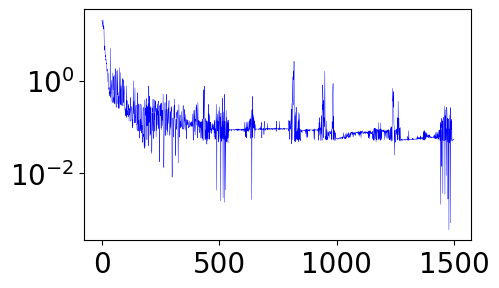

tune params:  6_env_params_noise=0.0002,model_latent_size=3
final loss:  0.0032200831919908
completed?  False


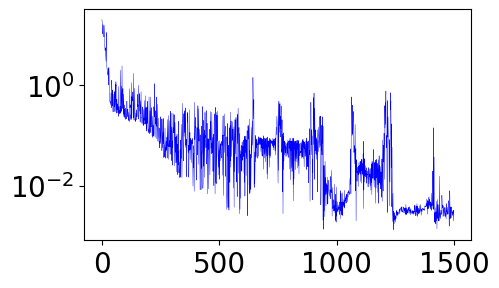

tune params:  7_env_params_noise=0.0002,model_latent_size=3
final loss:  0.0034093167632818
completed?  False


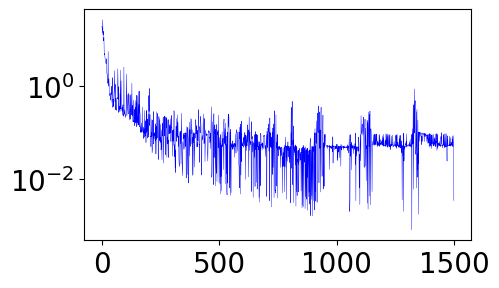

tune params:  5_env_params_noise=0.0002,model_latent_size=3
final loss:  0.0510653890669345
completed?  False


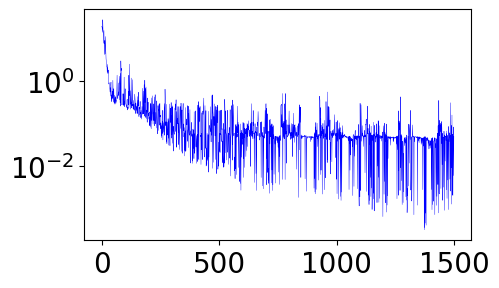

tune params:  2_env_params_noise=0.0002,model_latent_size=2
final loss:  0.0480935871601104
completed?  False


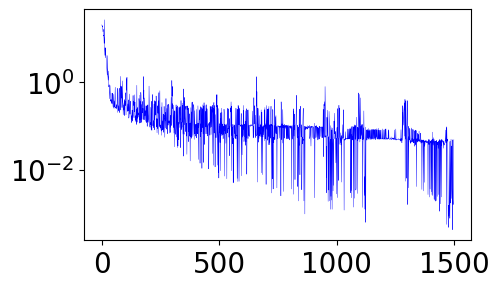

tune params:  0_env_params_noise=0.0001,model_latent_size=2
final loss:  0.0501014031469821
completed?  False


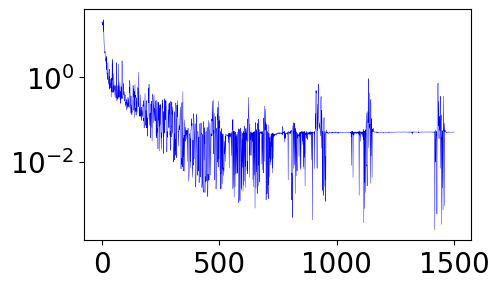

tune params:  1_env_params_noise=0.0002,model_latent_size=2
final loss:  0.0502433441579341
completed?  False


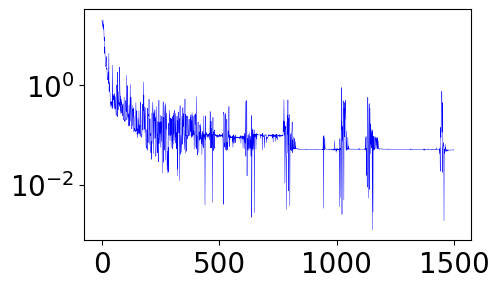

tune params:  4_env_params_noise=0.0001,model_latent_size=3
final loss:  0.195163607597351
completed?  False


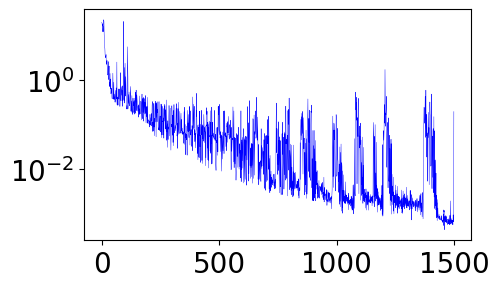

6_env_params_noise=0.0002,model_latent_size=3

7_env_params_noise=0.0002,model_latent_size=3

2_env_params_noise=0.0002,model_latent_size=2



In [8]:
# iterate over all tune runs and
# 1. create analysis folders
# 2. print the final val/train loss for each + the training dynamics
# 2. plot the trial io AND flow field + latents
# 3. select the best ones

import os
import pandas as pd
import matplotlib.pyplot as plt
import json

RUN_DIR = "/scratch/gpfs/ad2002/content/runs/task-trained/20250412_PC_gNODE_sweep"
TRAINED_MODELS_DIR = ""

TOTAL_ITERS = 2500
SHOW_LOSS_CURVES = True

dirs = os.listdir(RUN_DIR)
# retrieve the last training for that model and task
latest_dir = dirs[len(dirs)-1]
# get all hyperparam combs for the latest train run
tunes = os.listdir(RUN_DIR + "/" + latest_dir)
good_loss = []

for tune in tunes:
    
    prog_path = RUN_DIR + "/" + latest_dir + "/" + tune + '/progress.csv'
    params_path = RUN_DIR + "/" + latest_dir + "/" + tune + '/params.json'
    if os.path.exists(prog_path):
        df = pd.read_csv(prog_path)
        loss = df.iloc[:, 0]
        print("tune params: ", tune)
        print("final loss: ", loss[len(loss)-1])
        print("completed? ", len(loss) == TOTAL_ITERS)

        if loss[len(loss)-1] <= 0.05:
            good_loss.append(tune)
              
        if SHOW_LOSS_CURVES:
            fig, ax = plt.subplots(figsize=(5, 3), dpi=100)
            ax.plot(loss, linestyle="-", color="b", label="val loss", linewidth=0.3)
            ax.set_yscale('log')
            plt.show()

for word in good_loss:
    print(word + '\n')



In [8]:
from ctd.comparison.analysis.tt.tt import Analysis_TT

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250327_2BFF_NODE_verify/max_epochs=200_batch_size=128_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=5.00E-02_latent_size=3_layer_hidden_size=128_n=2"
# ver_node = Analysis_TT(run_name = "ver_node", filepath = path + "/")
# # ver_node.plot_trial_latents()

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250312_3BFF_frRNN/max_epochs=1000_weight_decay=1.00E-06_learning_rate=1.00E-02_seed=0_noise=0.00E+00_latent_size=64"
# ver_fr = Analysis_TT(run_name = "ver_fr", filepath = path + "/")
# ver_fr.plot_trial_latents(n_components = 2)

# path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_3BFF_frRNN_testFP/max_epochs=24_weight_decay=1.00E-06_learning_rate=5.00E-03_seed=0_noise=0.00E+00_latent_size=256"
# ver_fr_pc = Analysis_TT(run_name = "ver_fr_pc", filepath = path + "/")

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250329_3BFF_lrRNN_testFP/max_epochs=50_weight_decay=1.00E-06_learning_rate=1.00E-03_seed=0_noise=0.00E+00_latent_size=256_rank=2"
ver_lr_3bff = Analysis_TT(run_name = "ver_lr_pc", filepath = path + "/")

# print(ver_lr_3bff.wrapper.model.cell.recW1.weight)

## Verify methods w known NBFF results

All good - flow field not the best bc NODE model was not fully optimized

/home/ad2002/.conda/envs/ctd/lib/python3.10/site-packages/torch/cuda/__init__.py:734: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")



Iteration 500/10000
q = 7.60E-03 +/- 3.85E-02
dq = 6.02E-06 +/- 2.87E-05

Iteration 1000/10000
q = 6.57E-03 +/- 3.35E-02
dq = 8.59E-07 +/- 5.09E-06

Iteration 1500/10000
q = 6.05E-03 +/- 3.10E-02
dq = 1.36E-06 +/- 7.94E-06

Iteration 2000/10000
q = 5.11E-03 +/- 2.67E-02
dq = 2.46E-06 +/- 1.42E-05

Iteration 2500/10000
q = 3.63E-03 +/- 2.01E-02
dq = 3.26E-06 +/- 1.86E-05

Iteration 3000/10000
q = 2.04E-03 +/- 1.27E-02
dq = 3.01E-06 +/- 1.79E-05

Iteration 3500/10000
q = 7.88E-04 +/- 5.31E-03
dq = 1.80E-06 +/- 1.29E-05

Iteration 4000/10000
q = 2.42E-04 +/- 1.49E-03
dq = 5.49E-07 +/- 4.49E-06

Iteration 4500/10000
q = 8.63E-05 +/- 5.31E-04
dq = 1.71E-07 +/- 9.98E-07

Iteration 5000/10000
q = 2.98E-05 +/- 1.91E-04
dq = 7.03E-08 +/- 4.90E-07

Iteration 5500/10000
q = 9.56E-06 +/- 5.92E-05
dq = 2.06E-08 +/- 1.28E-07

Iteration 6000/10000
q = 4.14E-06 +/- 2.54E-05
dq = 7.44E-09 +/- 4.38E-08

Iteration 6500/10000
q = 2.12E-06 +/- 1.07E-05
dq = 4.62E-09 +/- 2.11E-08

Iteration 7000/10000
q = 

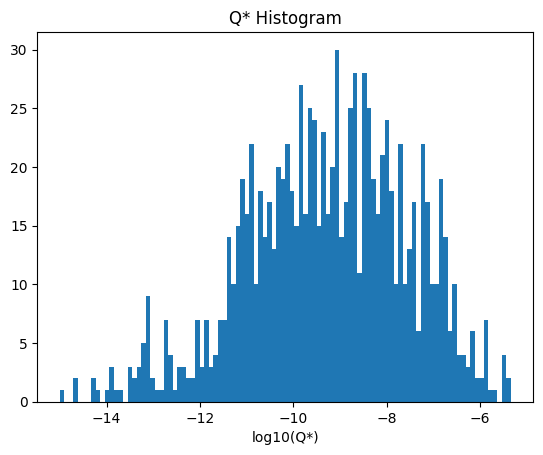

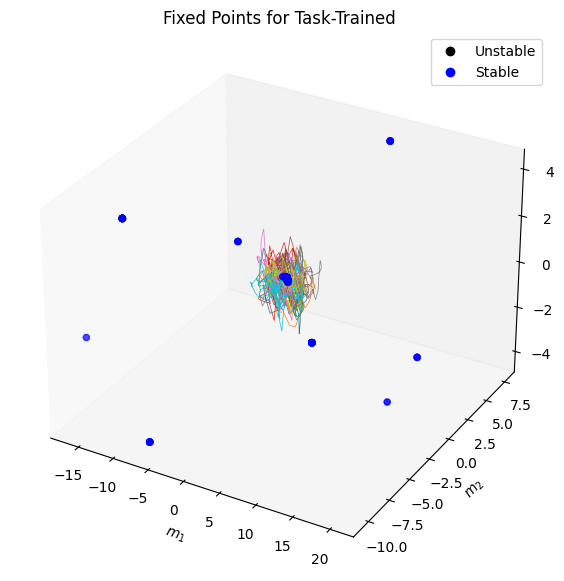

In [2]:
# print(ver_fr_pc.wrapper.model)
# running on 48 G - 12 cores

fps, xstar, q_flag, colors = ver_lr_pc.plot_fps(
                    num_traj=10,
                    n_inits=1024,
                    noise_scale=0.0,
                    learning_rate=1e-3,
                    max_iters=10000,
                    device="cpu",
                    seed=0,
                    compute_jacobians=True,
                    q_thresh=1e-3,
                    n_pca_components=3,
                    return_pca_model = False,
                    do_pca=True,
                    plot_only_points=False,
                    return_points = True,
                )

## Poisson clicks task

Using matplotlib backend: module://matplotlib_inline.backend_inline


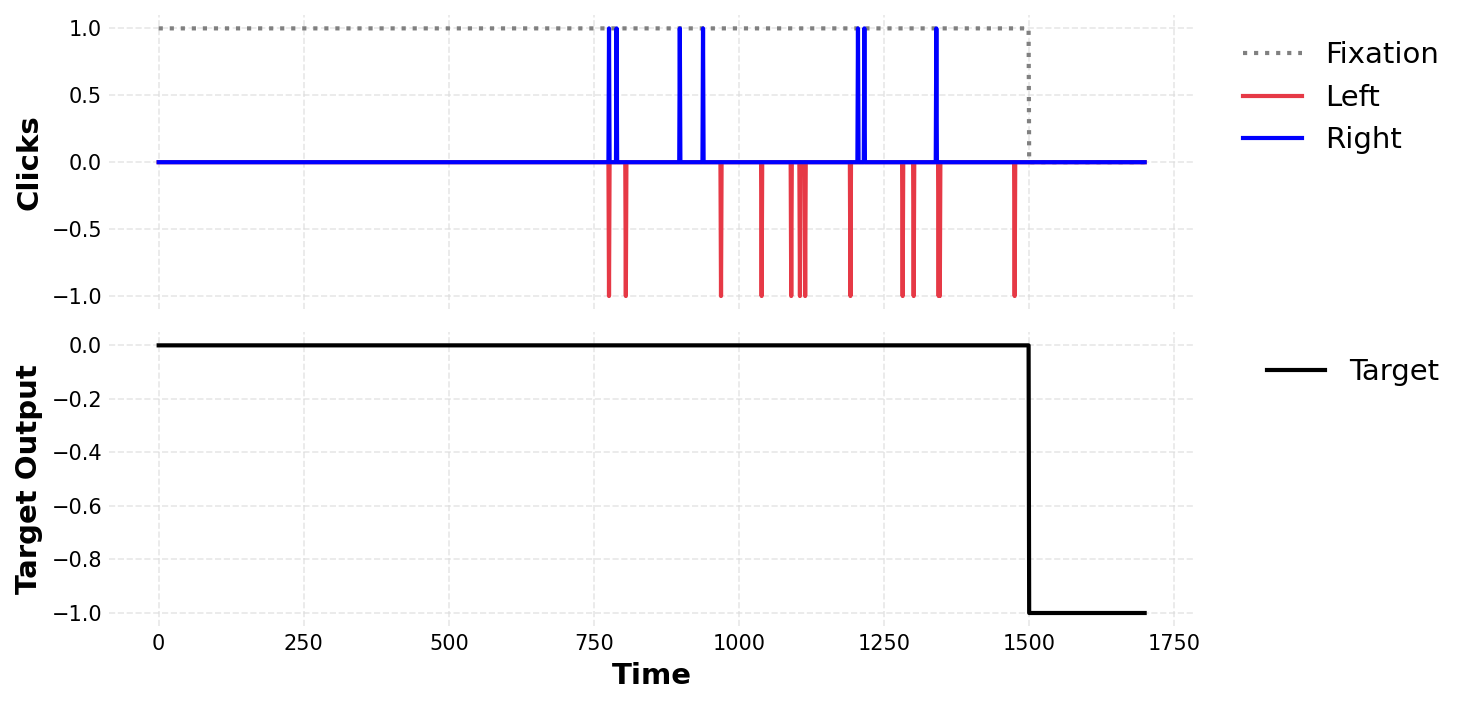

In [12]:
%matplotlib
from ctd.task_modeling.task_env.task_env import PClicks
import matplotlib.pyplot as plt

def render(self):
    inputs, outputs, _ = self.generate_trial()

    
    # Set up the figure with a specific figsize and higher DPI for better quality
    fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(10, 5), dpi=150)
    
    # Define better colors with more saturation
    left_click_color = '#E63946'  # Vibrant red
    right_click_color = 'blue'  # Deep blue
    output_color = 'black'  # Black for target output
    
    # Remove box borders from all subplots
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.tick_params(axis='both', which='both', length=0)
        ax.grid(True, linestyle='--', alpha=0.7, color='#DDDDDD')
    
    # Plot data with improved line width and style
    # Make fixation a dotted line
    axes[0].plot(inputs[:, 0], color='gray', linewidth=2, linestyle=':', label='Fixation')
    axes[0].plot(self.LEFT*inputs[:, 1], color=left_click_color, linewidth=2, label='Left')
    axes[0].plot(self.RIGHT*inputs[:, 2], color=right_click_color, linewidth=2, label='Right')
    axes[0].set_ylabel("Clicks", fontsize=14, fontweight='bold')
    
    # Make the legend big
    axes[0].legend(frameon=False, fontsize=14, loc='upper right', bbox_to_anchor=(1.25, 1))
    
    axes[1].plot(outputs, color=output_color, linewidth=2, label='Target')
    axes[1].set_ylabel("Target Output", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time", fontsize=14, fontweight='bold')
    
    # Also add legend to second plot and make it bigger
    axes[1].legend(frameon=False, fontsize=14 ,loc='upper right', bbox_to_anchor=(1.25, 1))
    
    # Improve spacing between subplots
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Save the figure as high resolution before showing (optional)
    # plt.savefig('input_output_task.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# Example usage
pc = PClicks(n_timesteps=2000, noise=0.00, rateL=24, delta_t=0.001, allRates=False)  # Hz
render(pc)
# dataset_dict, extra_dict = pc.generate_dataset(100)

# FPs, stability, timescales

In [3]:
# explicit jacobian computation - model=generator
# plot without pca and set x points to plot
import numpy as np

def J_func(model, inputs_, x):
            # This function takes both the additional inputs and the state.
            F = model(inputs_, x)
            return F.squeeze()

def compute_jacobians_func(model, inputs, x_data):
    all_J = []
    x = torch.tensor(x_data, device=device)
    for i in range(x.size(0)):
        inputs_1 = inputs[i, :].unsqueeze(0)
        single_x = x[i, :].unsqueeze(0)
        J = torch.autograd.functional.jacobian(
            lambda x: J_func(model, inputs_1, x), single_x
        )
        all_J.append(J.squeeze())
    return all_J


def compute_dynamical_metrics(J_xstar, eigval_J_xstar, eigvec_J_xstar):
    """
    Compute spectral abscissa, SATI, and related metrics from Jacobian and eigenvalue data.

    Parameters
    ----------
    J_xstar : ndarray of shape (n_points, n_states, n_states)
        Jacobians at low-velocity points.
    eigval_J_xstar : ndarray of shape (n_points, n_states)
        Eigenvalues of the Jacobians.
    eigvec_J_xstar : ndarray of shape (n_points, n_states, n_states)
        Eigenvectors (not used here but kept for future use).

    Returns
    -------
    metrics : dict
        Dictionary containing:
        - spectral_abscissa
        - sati
        - mean_imag_part
        - num_unstable_modes
        - jacobian_frobenius_norm
    """
    # Remove NaN entries
    valid = ~np.isnan(eigval_J_xstar).any(axis=1)
    eigvals = eigval_J_xstar[valid]
    J_valid = J_xstar[valid]

    n_points = eigvals.shape[0]

    # Spectral abscissa: max Re(λ) at each point
    spectral_abscissa = np.max(eigvals.real, axis=1)  # shape: (n_points,)

    # SATI: min |Re(λ)| at each point, then averaged over time
    min_abs_real = np.min(np.abs(eigvals.real), axis=1)  # shape: (n_points,)
    sati = np.mean(min_abs_real)

    # Imaginary part: mean over all eigs
    mean_imag_part = np.mean(np.abs(eigvals.imag))

    # Unstable modes: count of λ with Re(λ) > 0
    num_unstable_modes = np.sum(eigvals.real > 0, axis=1)  # shape: (n_points,)
    avg_unstable_modes = np.mean(num_unstable_modes)

    # Frobenius norm of Jacobians: rough measure of stiffness
    jacobian_frobenius_norm = np.linalg.norm(J_valid, axis=(1, 2))  # shape: (n_points,)
    avg_jacobian_norm = np.mean(jacobian_frobenius_norm)

    return {
        'spectral_abscissa': spectral_abscissa,
        'spectral_abscissa_mean': np.mean(spectral_abscissa),
        'sati': sati,
        'mean_imag_part': mean_imag_part,
        'avg_num_unstable_modes': avg_unstable_modes,
        'avg_jacobian_frobenius_norm': avg_jacobian_norm,
        'total_points_tested': n_points
    }


## TT Flow fields and different topologies - PCA projected

## GNODEs

In [15]:
#path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"
gnode_pc=Analysis_TT(run_name = "gru_pc", filepath =path + "/")

MAX=1e-8

for i in [[1,0,1], [1,1,0], [0,0,0], [1,0,0]]:

    # output of this function is already under threshold
    fps = gnode_pc.compute_FPs(noiseless=True,
                        inputs=np.array(i),  # explicitly testing for FPs in intrinsic field
                        n_inits=2056,
                        noise_scale=0.5,
                        learning_rate=1e-3,
                        max_iters=10000,
                        device="cpu",
                        seed=0,
                        compute_jacobians=True,
                        q_thresh=MAX,
                        early_stop_threshold=1e-8,
                       )
    
    with open(f"fps_gnode2_tt_{i}.pkl", "wb") as file:
        pickle.dump(fps, file)

Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 4.29E-01
Mean dq = 6.65E-04
Best q = 1.36E-08
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 5.90E-01
Mean dq = 8.76E-04
Best q = 1.36E-08
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 5.75E-01
Mean dq = 9.06E-04
Best q = 1.36E-08
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 6.56E-01
Mean dq = 9.45E-04
Best q = 1.16E-08
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 5.53E-01
Mean dq = 8.44E-04
Best q = 6.97E-10
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 5.59E-01
Mean dq = 8.05E-04
Best q = 6.97E-10
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 4.37E-01
Mean dq = 6.72E-04
Best q = 6.97E-10
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 4.36E-01
Mean dq = 6.50E-04
Best q = 6.97E-10
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 2.81E-01
Mean dq = 5.03E-04
Best q = 6.97E-10
Temperature = 5.50E-01

Iteration 5000/10000
Mean q = 2.64E-01
Mean dq = 4.


Iteration 9000/10000
Mean q = 6.17E-03
Mean dq = 1.53E-05
Best q = 0.00E+00
Temperature = 1.00E-01

Iteration 9500/10000
Mean q = 1.17E-03
Mean dq = 4.25E-06
Best q = 0.00E+00
Temperature = 5.00E-02

Iteration 10000/10000
Mean q = 5.93E-04
Mean dq = 1.92E-06
Best q = 0.00E+00
Temperature = 5.00E-02
Found 141 unique fixed points.
Decomposing Jacobians in a single batch.
Sorting by Eigenvalue magnitude.


/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True
loss:  0.0009994455613195896
PCA explained variance: PC1=0.9826, PC2=0.0174
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting 141 fixed points


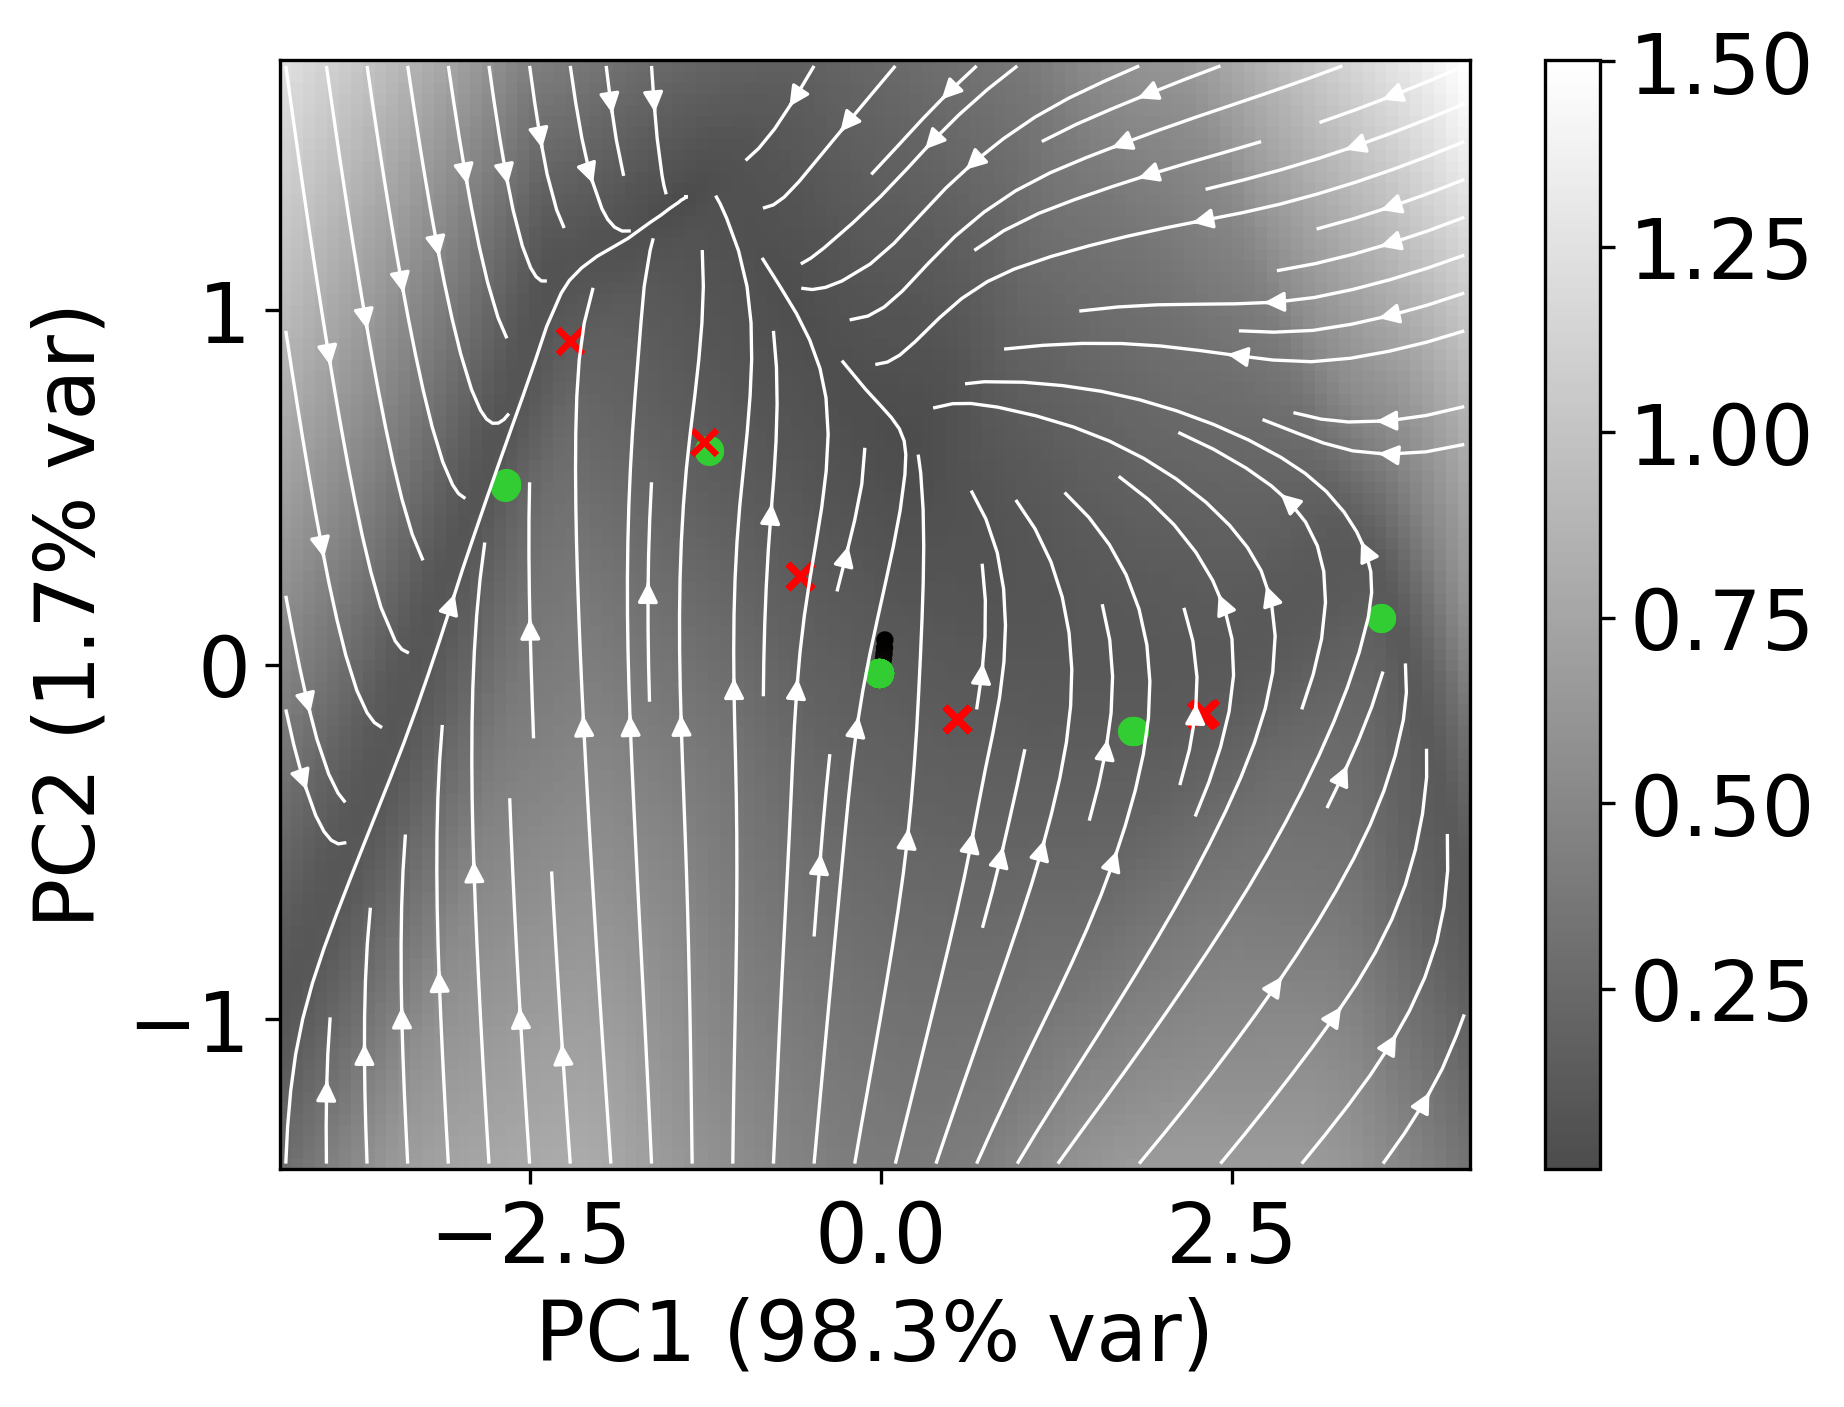

In [16]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"

# for delta_t 1e-2
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=False, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

with open("fps_gnode2_tt_[1, 0, 0].pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-8]
    
fig, ax = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,   
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-5,5],[-5,5]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                    phase="delay",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                 )
fig.set_dpi(300)

In [ ]:
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

In [ ]:
# ONE W BETTER LOSS BUT WEIRD FLOW
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=1.00E-01_leak=True"

fig = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([0,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-10,10],[-10,10]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                    phase="all",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                 )
fig.set_dpi(300)

# LOOK INTO GATING AND WRITE ABOUT IT

In [2]:
# BEST_GNODE = /scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True
# or /scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep/max_epochs=1500_weight_decay=1.00E-06_learning_rate=2.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=64_delta_t=1.00E-02_alpha=1.00E-01_leak=True

import re

sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250412_PC_gNODE_sweep"
# sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final"

for dirpath, dirnames, filenames in os.walk(sweep_dir):
    for dirname in dirnames:

        pattern = r"latent_size=(\d+)"
        match = re.search(pattern, dirname)

        if match.group(1) == '2':
            
            analyze_flow_field(sweep_dir, 
                    sweep_name=os.path.join(sweep_dir, dirname),
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,1]),   # clicks: right, left
                    n_trials=500,
                    scatter=False,    # if True, won't color by rate
                    intrinsic=True, 
                    plot_wrapper_trajs=True,
                    avg_per_rate=False,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=50,
                    latents_range=[[-5,5],[-5,5]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                   )


NameError: name 'os' is not defined

## NODEs

In [57]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"
node_pc=Analysis_TT(run_name = "gru_pc", filepath =path + "/")

MAX=1e-8

for i in [[0,0,0], [1,0,0]]:

    # output of this function is already under threshold
    fps = node_pc.compute_FPs(noiseless=True,
                        inputs=np.array(i),  # explicitly testing for FPs in intrinsic field
                        n_inits=2056,
                        noise_scale=0.5,
                        learning_rate=1e-3,
                        max_iters=10000,
                        device="cpu",
                        seed=0,
                        compute_jacobians=True,
                        q_thresh=MAX,
                        early_stop_threshold=1e-8,
                       )
    
    with open(f"fps_gnode_tt_{i}.pkl", "wb") as file:
        pickle.dump(fps, file)


Optimizing from 6168 initial points in 3 batches

Iteration 500/10000
Mean q = 2.83E-01
Mean dq = 5.41E-04
Best q = 0.00E+00
Temperature = 9.50E-01

Iteration 1000/10000
Mean q = 3.82E-01
Mean dq = 5.48E-04
Best q = 0.00E+00
Temperature = 9.00E-01

Iteration 1500/10000
Mean q = 4.05E-01
Mean dq = 5.32E-04
Best q = 0.00E+00
Temperature = 8.50E-01

Iteration 2000/10000
Mean q = 4.47E-01
Mean dq = 5.38E-04
Best q = 0.00E+00
Temperature = 8.00E-01

Iteration 2500/10000
Mean q = 4.02E-01
Mean dq = 4.97E-04
Best q = 0.00E+00
Temperature = 7.50E-01

Iteration 3000/10000
Mean q = 4.12E-01
Mean dq = 5.01E-04
Best q = 0.00E+00
Temperature = 7.00E-01

Iteration 3500/10000
Mean q = 3.33E-01
Mean dq = 4.61E-04
Best q = 0.00E+00
Temperature = 6.50E-01

Iteration 4000/10000
Mean q = 3.31E-01
Mean dq = 4.53E-04
Best q = 0.00E+00
Temperature = 6.00E-01

Iteration 4500/10000
Mean q = 2.76E-01
Mean dq = 4.02E-04
Best q = 0.00E+00
Temperature = 5.50E-01

Iteration 5000/10000
Mean q = 2.62E-01
Mean dq = 3.

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9745, PC2=0.0255
Total variance explained: 1.0000
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 18 fixed points


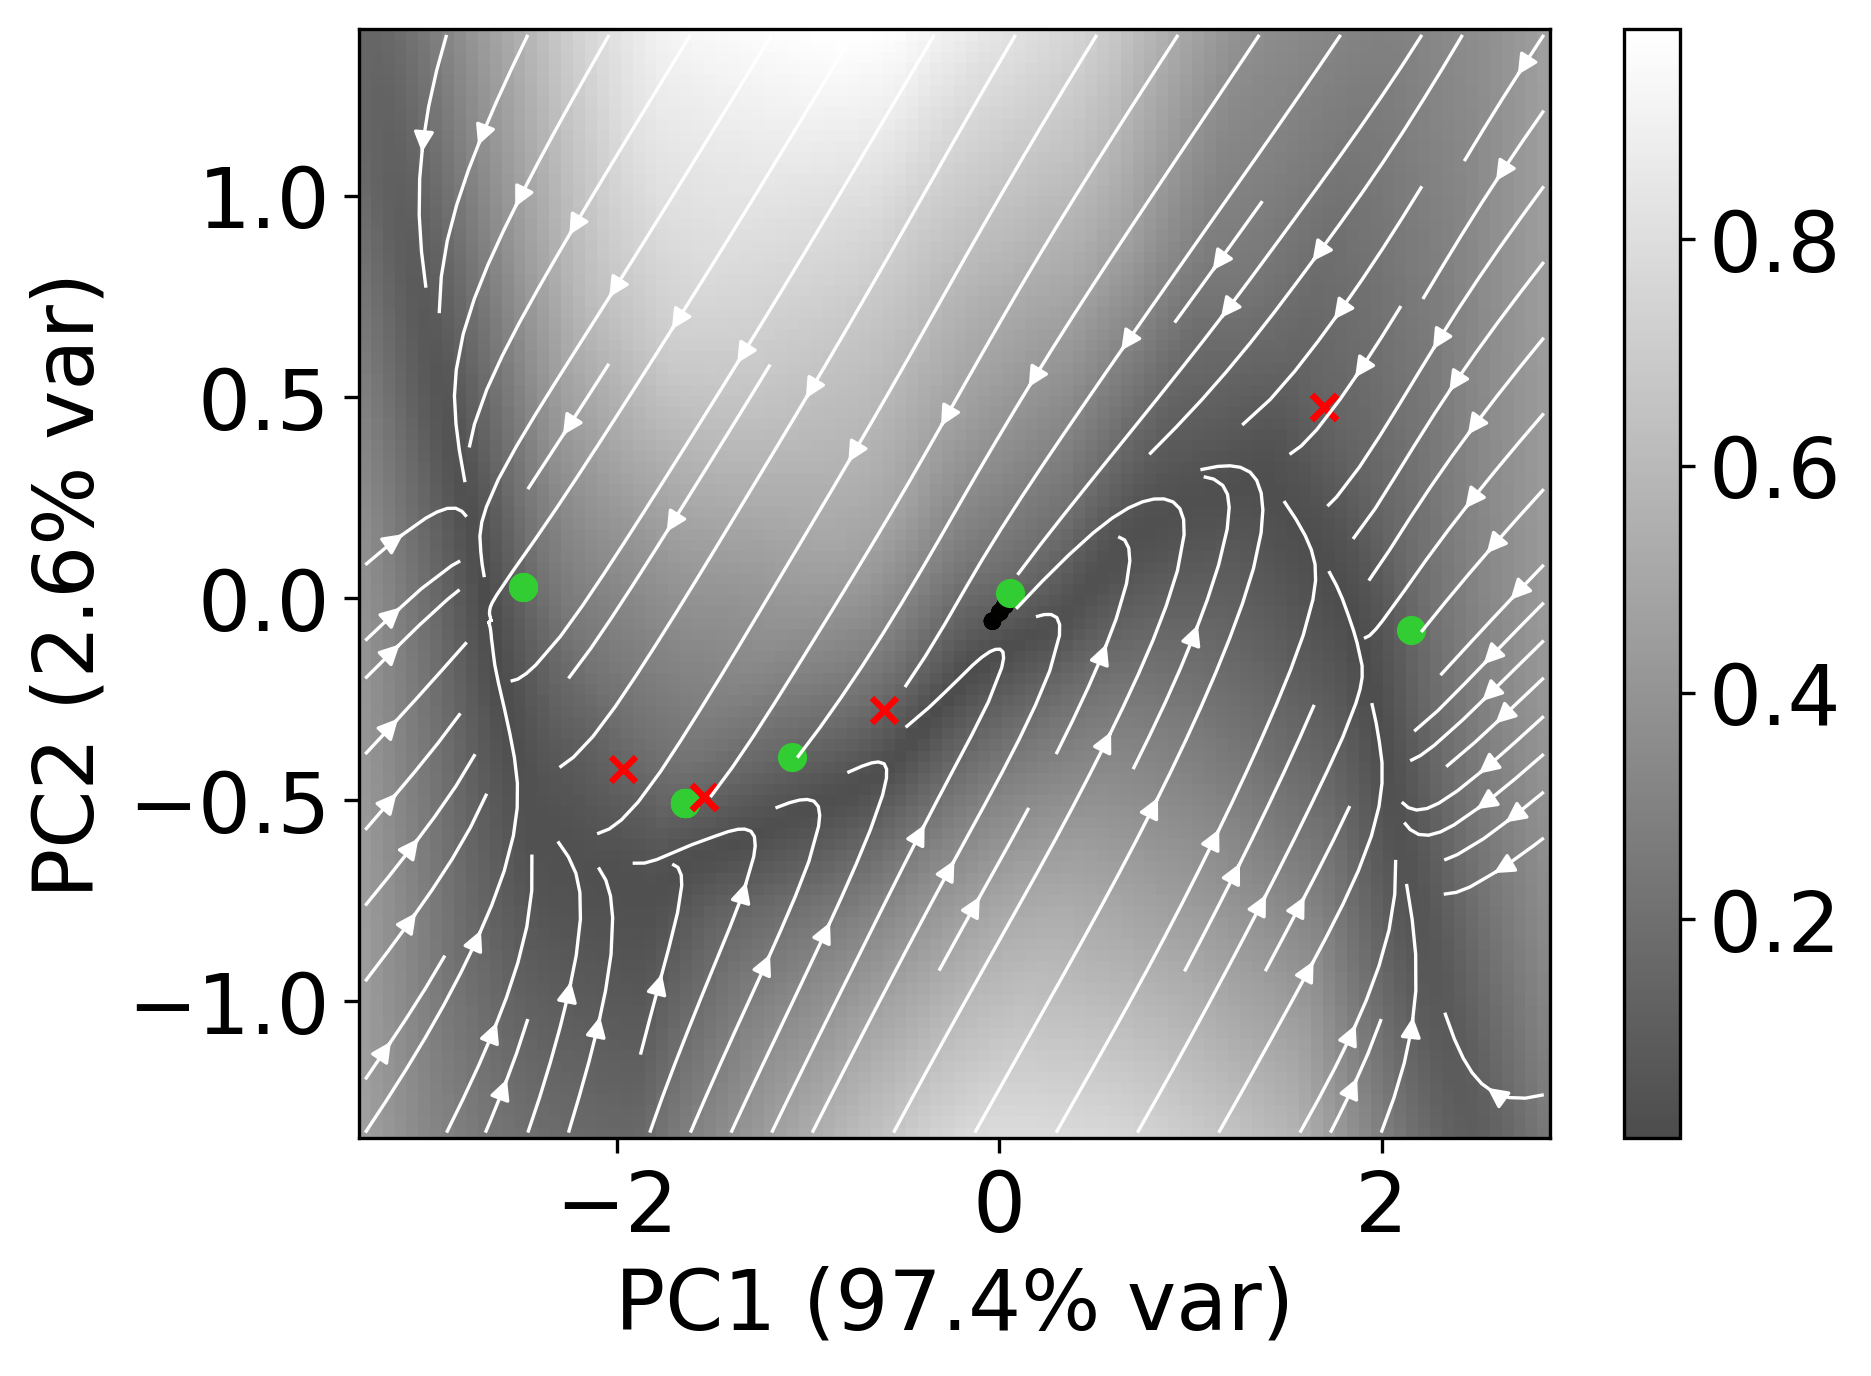

In [69]:
# for delta_t 1e-2
pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
pc_loss_func = pc1e2.loss_func

path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

with open("fixed_points/fps_node_tt_100.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-10]
    
fig = analyze_flow_field(sweep_dir="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final", 
                    sweep_name=path,
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,0]),   # 1,0=39   #1 = on fixation during stimulus
                    n_trials=2000,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=True,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-3,3],[-3,3]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                    phase="delay",
                    xstar = fps.xstar,
                    is_stable = fps.is_stable,
                 )
fig.set_dpi(300)

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.19907721877098083
PCA explained variance: PC1=0.9680, PC2=0.0320
Total variance explained: 1.0000


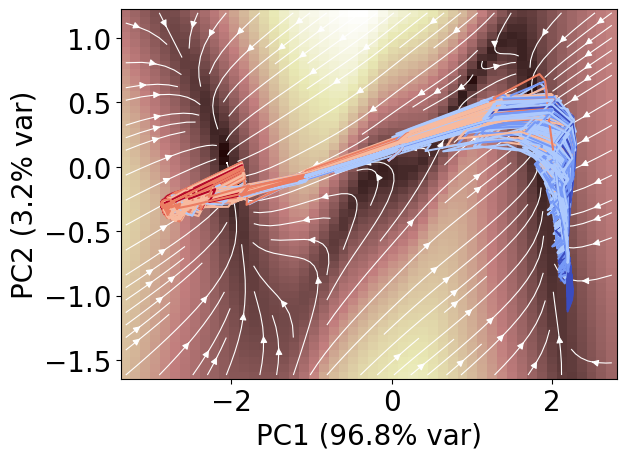

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.30E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09990359097719193
PCA explained variance: PC1=0.9859, PC2=0.0141
Total variance explained: 1.0000


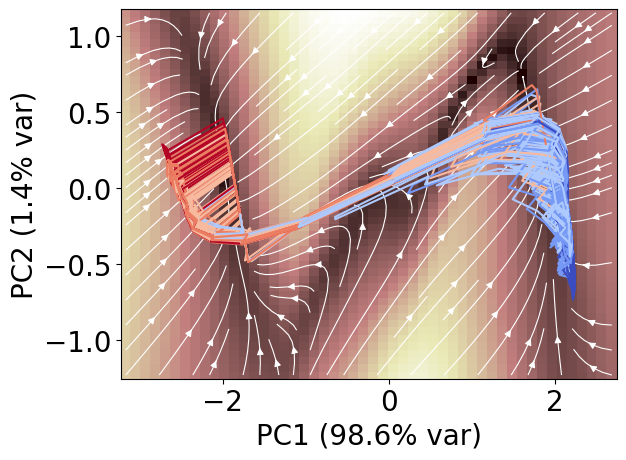

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.50E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.1850494146347046
PCA explained variance: PC1=0.9783, PC2=0.0217
Total variance explained: 1.0000


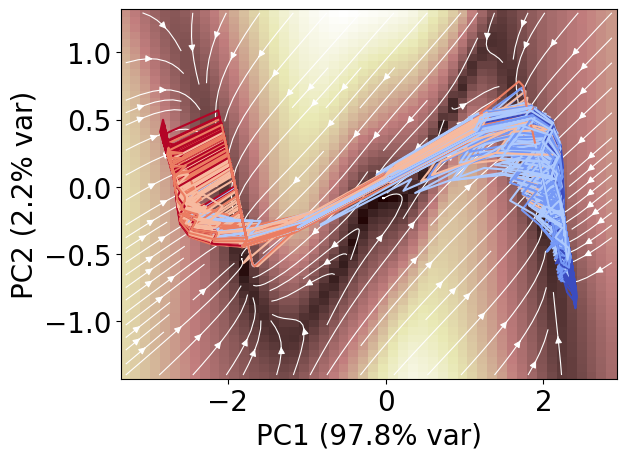

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.10E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.1003686934709549
PCA explained variance: PC1=0.9685, PC2=0.0315
Total variance explained: 1.0000


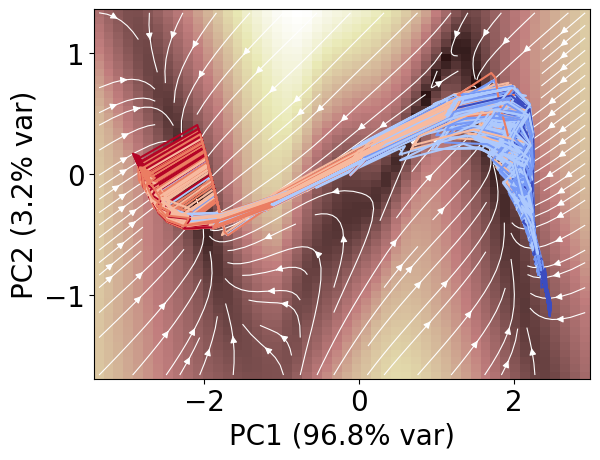

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.60E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.1375695765018463
PCA explained variance: PC1=0.9700, PC2=0.0300
Total variance explained: 1.0000


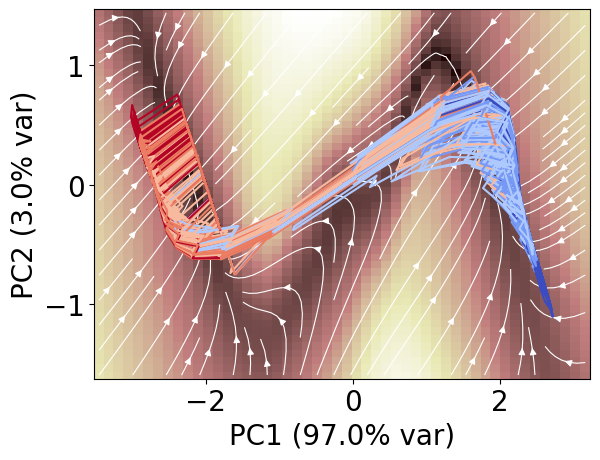

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.40E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09437541663646698
PCA explained variance: PC1=0.9500, PC2=0.0500
Total variance explained: 1.0000


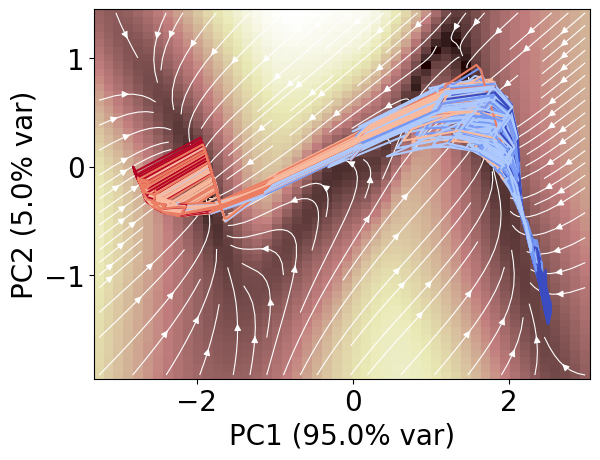

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.80E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.10061337798833847
PCA explained variance: PC1=0.9822, PC2=0.0178
Total variance explained: 1.0000


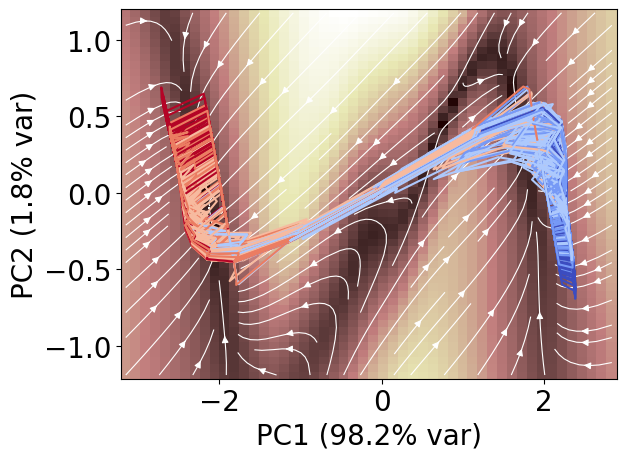

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.90E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.12718194723129272
PCA explained variance: PC1=0.9788, PC2=0.0212
Total variance explained: 1.0000


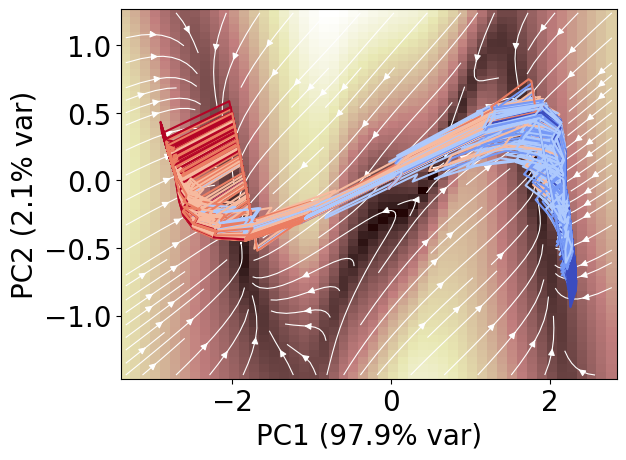

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.09023550152778625
PCA explained variance: PC1=0.9745, PC2=0.0255
Total variance explained: 1.0000


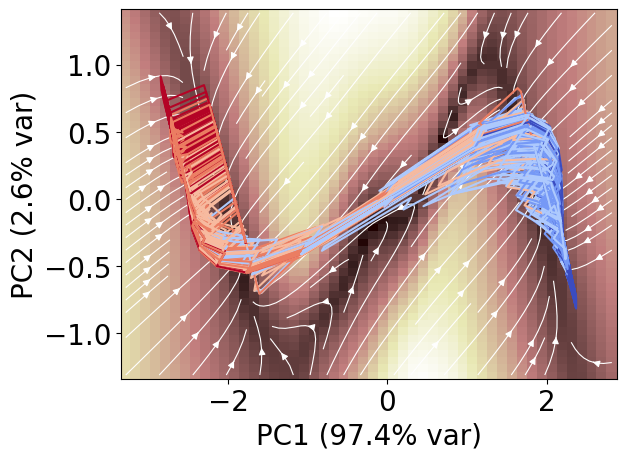

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=0.00E+00_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
loss:  0.14925821125507355
PCA explained variance: PC1=0.9807, PC2=0.0193
Total variance explained: 1.0000


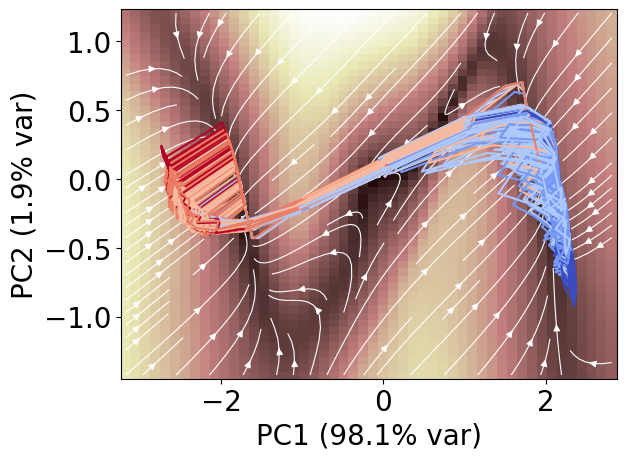

In [13]:
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final"

for dirpath, dirnames, filenames in os.walk(sweep_dir):
    for dirname in dirnames:

        pattern = r"latent_size=(\d+)"
        match = re.search(pattern, dirname)

        if match.group(1) == '2':
            
            analyze_flow_field(sweep_dir, 
                    sweep_name=os.path.join(sweep_dir, dirname),
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,1]),   # clicks: right, left
                    n_trials=500,
                    scatter=False,    # if True, won't color by rate
                    intrinsic=True, 
                    plot_wrapper_trajs=True,
                    avg_per_rate=False,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=50,
                    latents_range=[[-5,5],[-5,5]],
                    pca=True,
                    task_loss_func=pc_loss_func,
                   )

## nGRUs

Supposed to be a model of high capacity - but can only visualize trajs in dim 2

In [9]:
# DONT EXPECT TO SEE ANY
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2"
tune_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

gru_pc=Analysis_TT(run_name = "gru_pc", filepath =tune_dir + "/")

MAX=1e-5

for i in [[0,0,0], [1,0,0], [1,1,0], [1,0,1]]:

    # output of this function is already under threshold
    fps = gru_pc.compute_FPs(noiseless=True,
                        inputs=np.array(i),  # explicitly testing for FPs in intrinsic field
                        n_inits=2056,
                        noise_scale=0.1,
                        learning_rate=1e-2,
                        max_iters=5000,
                        device="cpu",
                        seed=0,
                        compute_jacobians=True,
                        q_thresh=MAX,
                        early_stop_threshold=1e-8,
                       )
    
    name = "fps_gru_tt_"
    for j in i:
        name += str(j)
    name += ".pkl"
    with open(name, "wb") as file:
        pickle.dump(fps, file)


Optimizing from 6168 initial points in 3 batches

Iteration 500/5000
Mean q = 9.09E-01
Mean dq = 1.06E-02
Best q = 2.97E-13
Temperature = 9.00E-01

Iteration 1000/5000
Mean q = 7.91E-01
Mean dq = 6.01E-03
Best q = 5.64E-14
Temperature = 8.00E-01

Iteration 1500/5000
Mean q = 4.69E-01
Mean dq = 3.21E-03
Best q = 4.98E-14
Temperature = 7.00E-01

Iteration 2000/5000
Mean q = 2.91E-01
Mean dq = 1.68E-03
Best q = 4.98E-14
Temperature = 6.00E-01

Iteration 2500/5000
Mean q = 1.50E-01
Mean dq = 7.92E-04
Best q = 4.98E-14
Temperature = 5.00E-01

Iteration 3000/5000
Mean q = 9.01E-02
Mean dq = 3.72E-04
Best q = 4.98E-14
Temperature = 4.00E-01

Iteration 3500/5000
Mean q = 4.61E-02
Mean dq = 1.45E-04
Best q = 4.98E-14
Temperature = 3.00E-01

Iteration 4000/5000
Mean q = 2.78E-02
Mean dq = 5.79E-05
Best q = 1.66E-14
Temperature = 2.00E-01

Iteration 4500/5000
Mean q = 1.24E-02
Mean dq = 1.64E-05
Best q = 1.66E-14
Temperature = 1.00E-01

Iteration 5000/5000
Mean q = 8.14E-03
Mean dq = 6.67E-06
Bes

PCA explained variance: PC1=0.8284 PC2=0.1505
Total variance explained: 0.9789
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting for non-trivial inputs with phase averaging
Plotting 820 fixed points


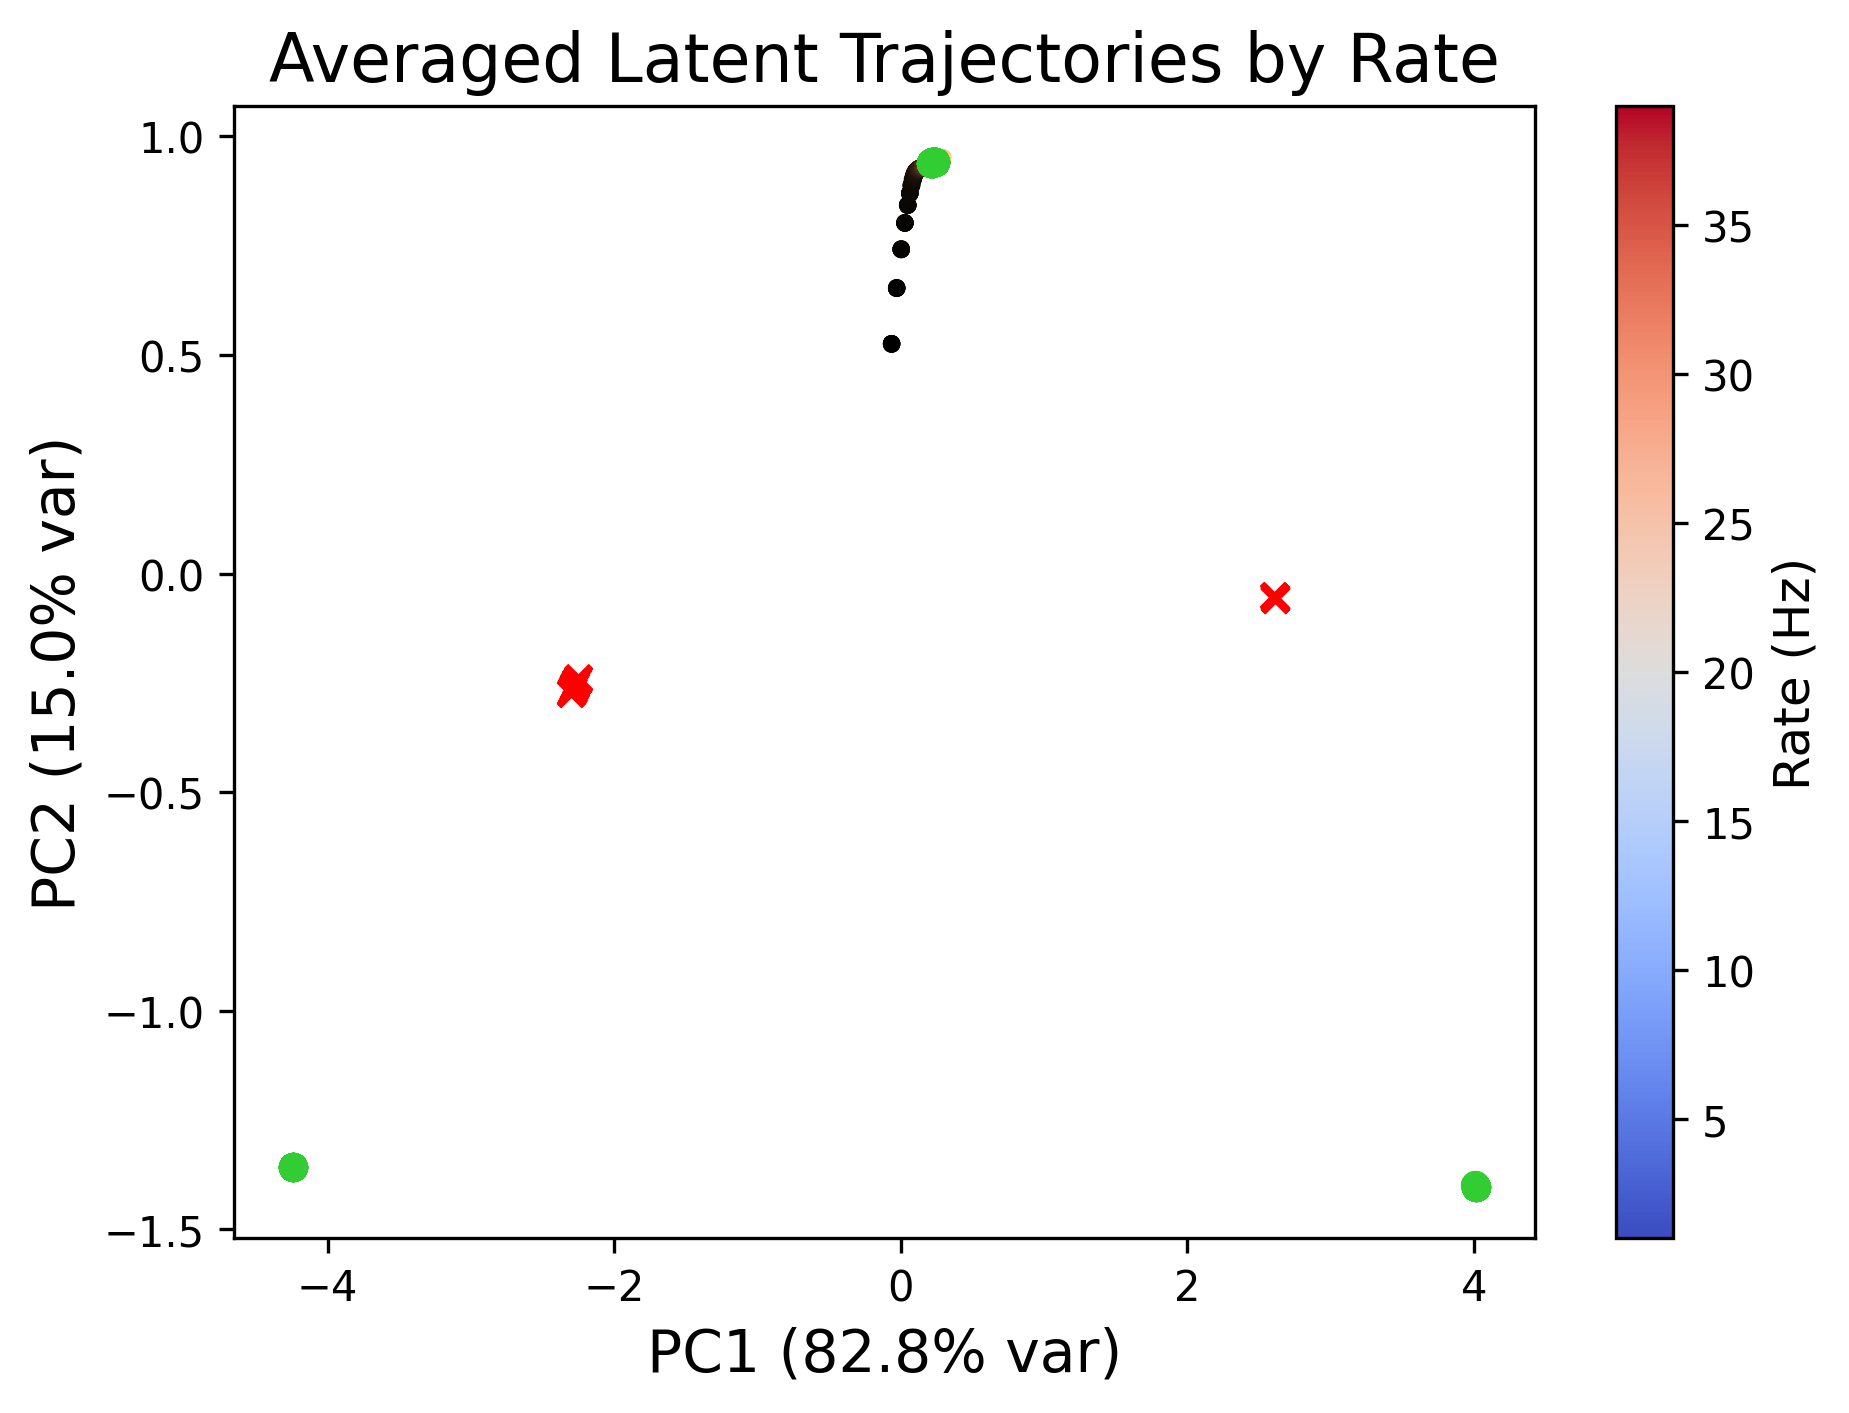

In [11]:
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2"
tune_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250413_PClicks_NoisyGRU_final2/max_epochs=1500_weight_decay=1.00E-04_learning_rate=1.00E-04_noise=5.00E-04_seed=0_latent_size=128_delta_t=1.00E-02_latent_ic_var=5.00E-03_l2_wt=1.00E-05_noise_level=5.00E-03"

pc1e2 = PClicks(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=39,               # Hz
             delta_t=1e-2,           # seconds
             allRates=True, 
             fixation_period = 1.5,  # seconds
             response_period = 0.8,  # seconds 
             delay_min = 0.5,          # seconds
             delay_max = 1.3, 
            ) 
d1e2, _ = pc1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset
task_dataset_dict=d1e2

intrinsic=False

inputs_latents = task_dataset_dict["inputs"]
        
if intrinsic:
    inputs_latents = np.zeros_like(inputs_latents)


with open("fps_gru_tt_100.pkl", "rb") as file:
    fps = pickle.load(file)
    fps = fps[fps.qstar <= 1e-8]
    

gru_pc = Analysis_TT(run_name = "gru_pc", filepath = tune_dir + "/")
fig = gru_pc.plot_trial_latents_new(num_trials=2000, 
                                    pca=True, 
                                    n_components=2, 
                                    avg_per_rate=True,
                                    xstar=fps.xstar, 
                                    is_stable=fps.is_stable, 
                                    phase="delay", 
                                    inputs_latents=inputs_latents,
                                    plot_wrapper_trajs=False, 
                                    input_latents_extra=task_dataset_dict["extra"],
                                    scatter_trajectories=True)
fig.set_dpi(300)

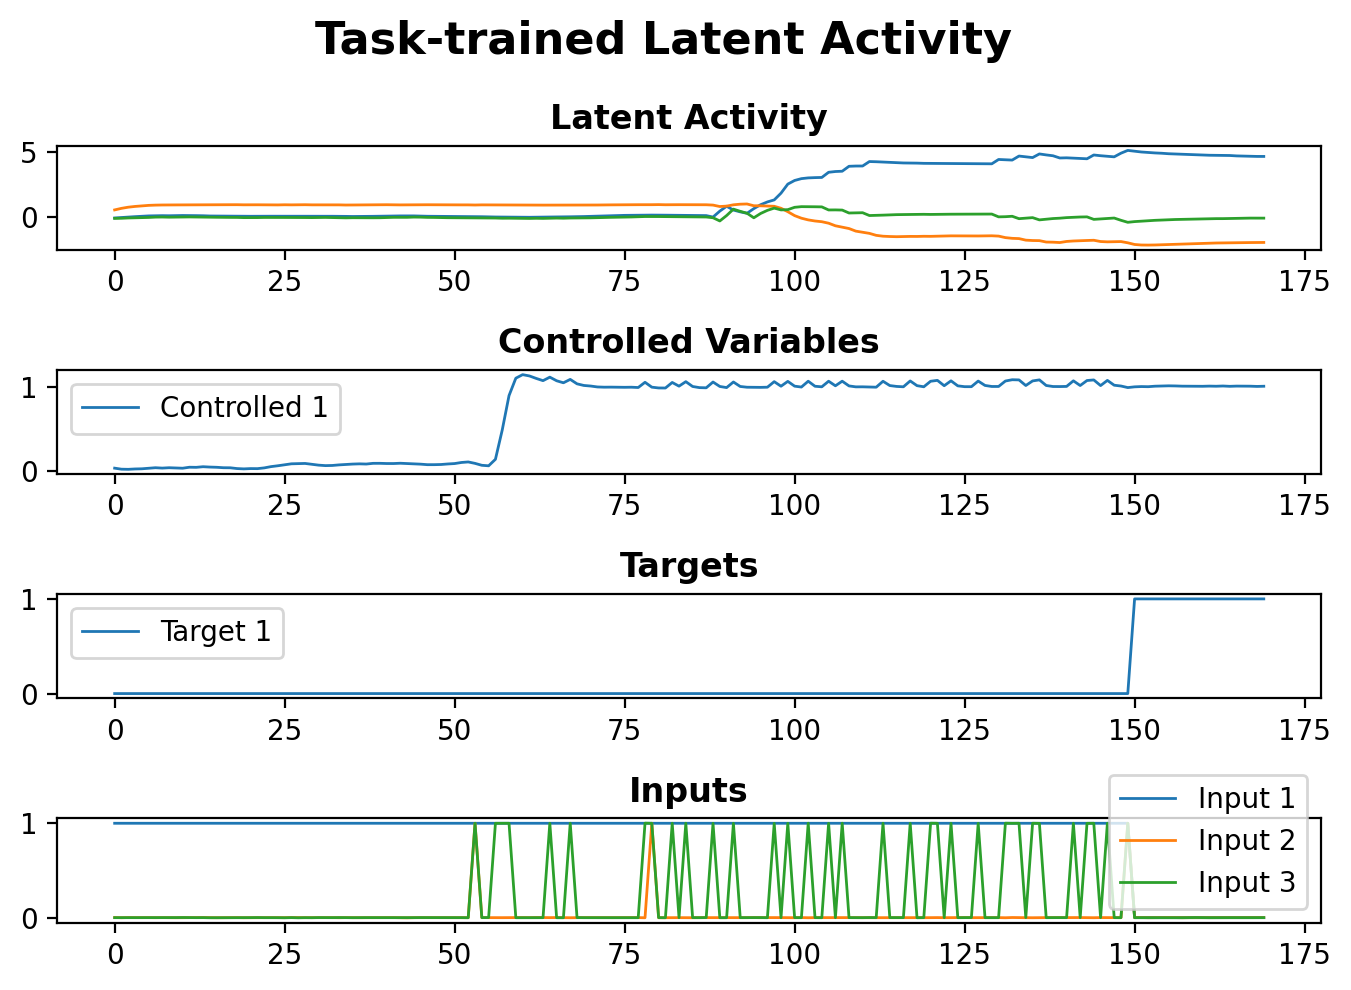

In [42]:
plot_trial_io(gru_pc, num_trials=1, single_trial_mode=True)

## TT - NODE - grid all flow fields size=2 w/ params

* runs also with size=2,3,5,10 but NOT visualized here (see below for trajs)
* here with dt in sec, before dt=tau (TO-DO: which one is better?)

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True


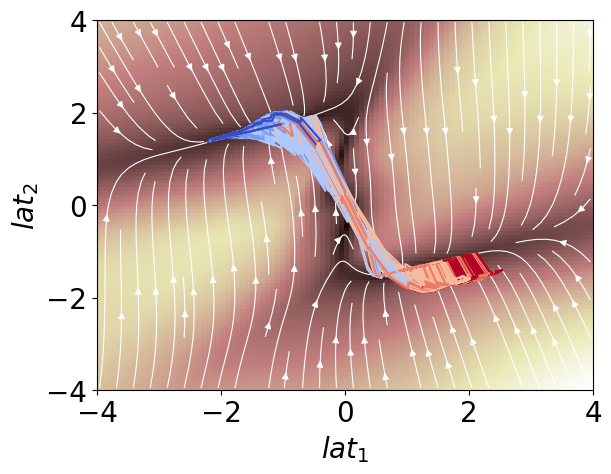

In [22]:
BEST_NODE = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True"

sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final"

# want to get intrinsic field but NOT the presaved latents
analyze_flow_field(sweep_dir, 
                    sweep_name="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True",
                    task_dataset_dict = d1e2, 
                    input_field=np.array([1,0,1]),   # clicks: right, left
                    n_trials=500,
                    scatter=False,    # if True, won't color by rate
                    intrinsic=True, 
                    plot_wrapper_trajs=True,
                    avg_per_rate=False,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-4,4],[-4,4]]
                   )

# advangin on the intrinsic field for IC in the origin does not advance them - adding some noise to the ics

# note that 0 seems to be a saddle point - unstable equilibirum

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.20E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


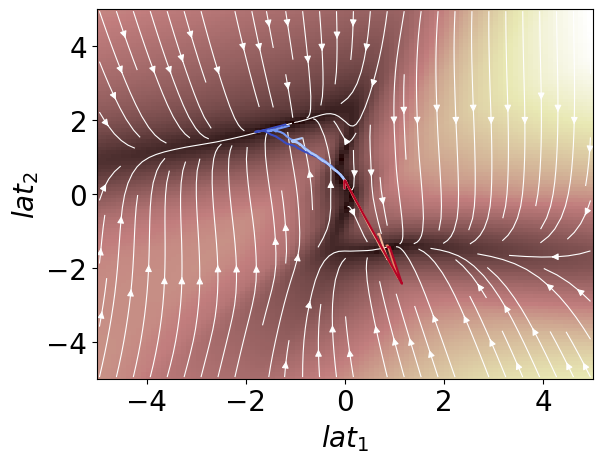

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.30E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


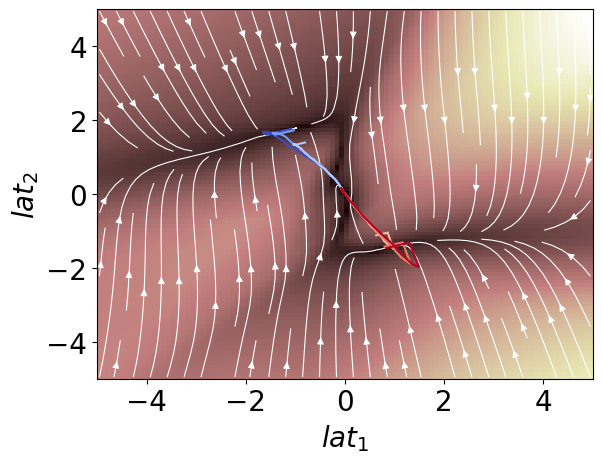

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.50E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


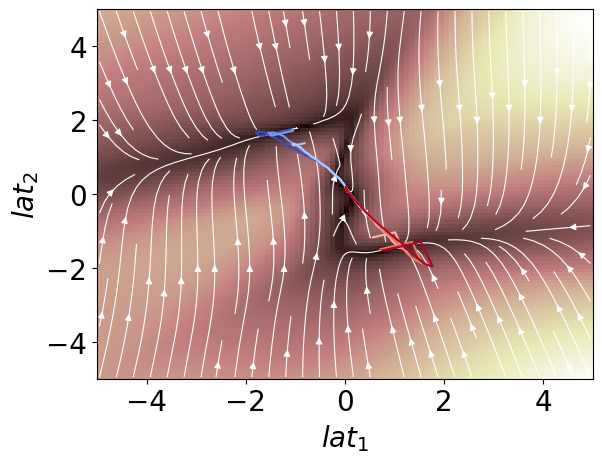

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.10E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


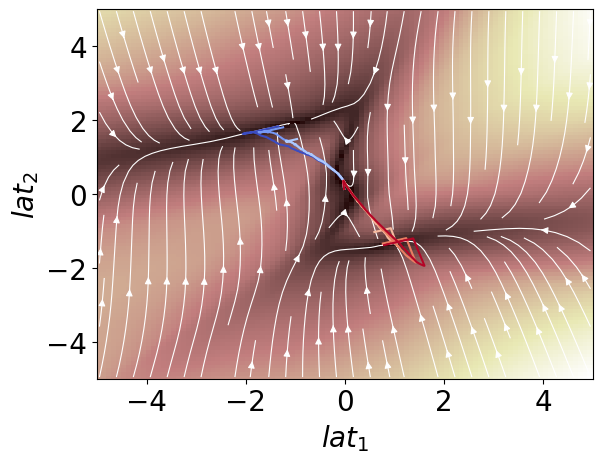

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.60E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


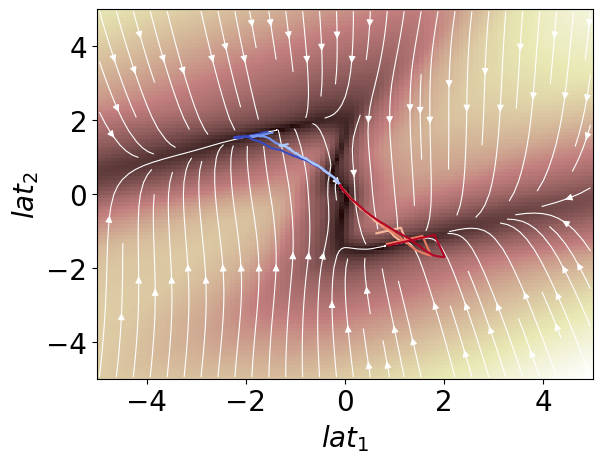

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.40E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


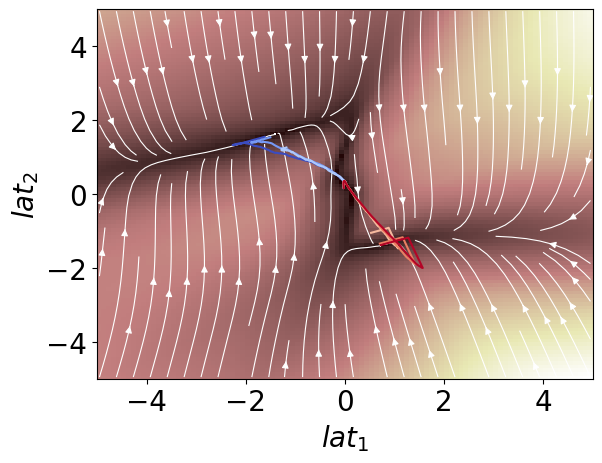

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.80E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


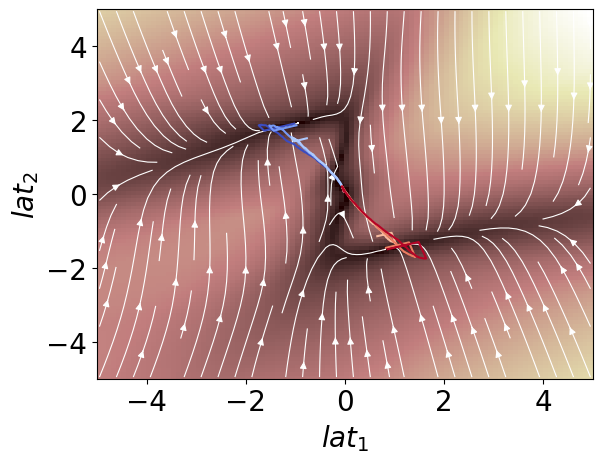

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.90E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


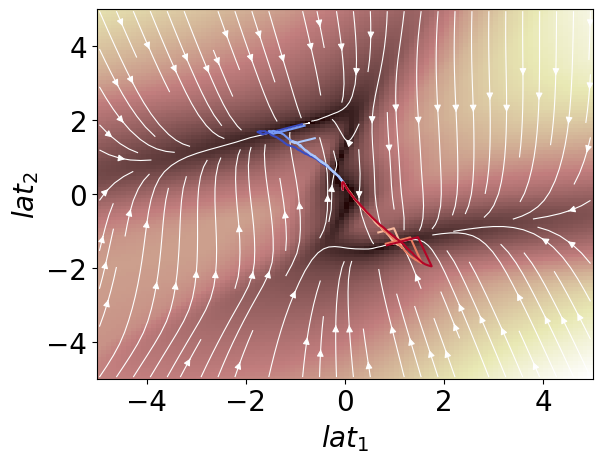

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


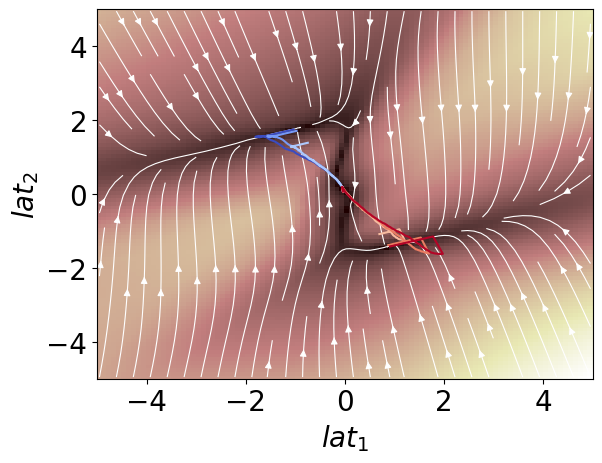

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final/max_epochs=1500_weight_decay=1.00E-08_learning_rate=1.00E-03_seed=0_noise=0.00E+00_latent_size=2_layer_hidden_size=128_delta_t=1.00E-02_alpha=5.00E-02_leak=True
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging
Plotting for all zero inputs - no phase averaging


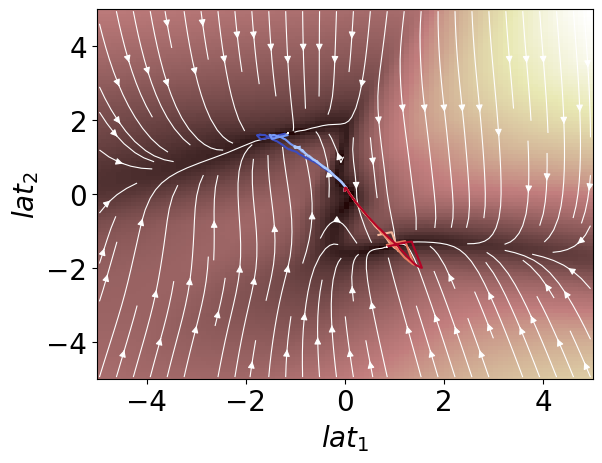

In [34]:
# quick loop over all tunes in a sweep to get the intrinsic field + wrapper saved trajs
import re
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250407_PC_NODE_grid_final"

for dirpath, dirnames, filenames in os.walk(sweep_dir):
    for dirname in dirnames:

        pattern = r"latent_size=(\d+)"
        match = re.search(pattern, dirname)

        if match.group(1) == '2':
            
            analyze_flow_field(sweep_dir, 
                        sweep_name=os.path.join(sweep_dir, dirname),
                        task_dataset_dict = d1e2, 
                        input_field=np.array([1,1,0]),   # clicks: right, left
                        n_trials=100,
                        scatter=False,    # if True, won't color by rate
                        intrinsic=True, 
                        plot_wrapper_trajs=True,
                        avg_per_rate=True,
                        filter_pc_rate=None,
                        lint_plot_style=True,
                        num_points=100,
                       )

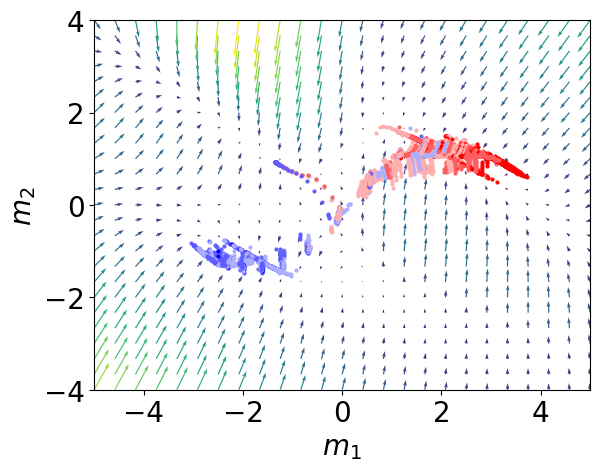

In [9]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import torch

node2_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250404_PClicks_NODE_grid_allRates_3/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=0.00E+00_allRates=True_latent_size=2_layer_hidden_size=128_delt=1.00E-01_leak=True"

node2_pc = Analysis_TT(run_name = "node1", filepath = node2_pc + "/")

node2_pc.plot_flow_field(latents_range = [[-5,5],[-4,4]], num_points = 25, inputs = torch.zeros(1,3), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=50, cmap=plt.cm.viridis, scatter_trajectories=True,
                        params = None, noiseless=False, pc_color=True)

# option to only show the hue of the velocity magnitude
# color code the trajectories by difficulty and orientation

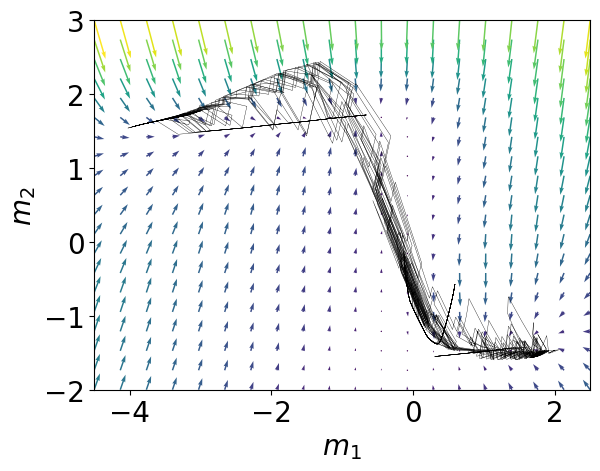

In [10]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
import matplotlib.pyplot as plt
import numpy as np
import torch

# decreased deltaT
node2_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250403_PClicks_NODE_grid_allRates_2/max_epochs=500_weight_decay=1.00E-10_learning_rate=1.00E-03_seed=0_noise=0.00E+00_allRates=True_latent_size=2_layer_hidden_size=64_delt=1.00E-03_leak=True"

node2_pc = Analysis_TT(run_name = "node1", filepath = node2_pc + "/")

node2_pc.plot_flow_field(latents_range = [[-4.5,2.5],[-2,3]], num_points = 20, inputs = torch.zeros(1,3), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=25, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False, intrinsic=False)


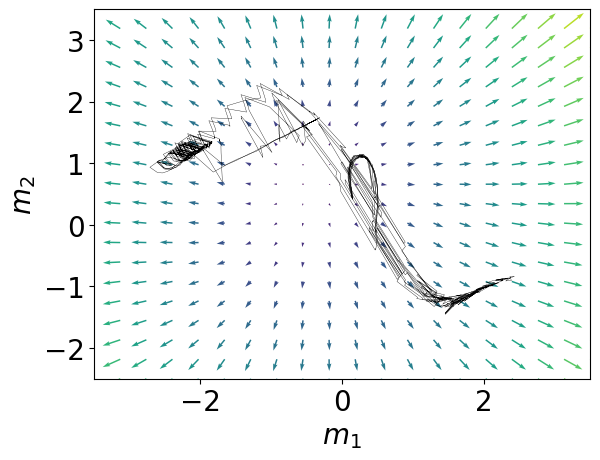

In [11]:
# say above is DD (stretch, would be a good one) and this one for TT (or viceversa)
import torch
import matplotlib.pyplot as plt
from ctd.comparison.analysis.tt.tt import Analysis_TT

node2_pc_worse = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=5.00E-02_allRates=True_latent_size=2_layer_hidden_size=64_latent_l2_wt=1.00E-08"

node2_pc_worse = Analysis_TT(run_name = "node1", filepath = node2_pc_worse + "/")
#torch.tensor([[0,1,0]])
node2_pc_worse.plot_flow_field(latents_range = [[-3.5,3.5],[-2.5,3.5]], num_points = 20, inputs = torch.tensor([[1,0,1]]), xstar=None, 
                        q_flag=None, colors_fps=None, num_traj=10, cmap=plt.cm.viridis, scatter_trajectories=False,
                        params = None, noiseless=False, intrinsic=True)

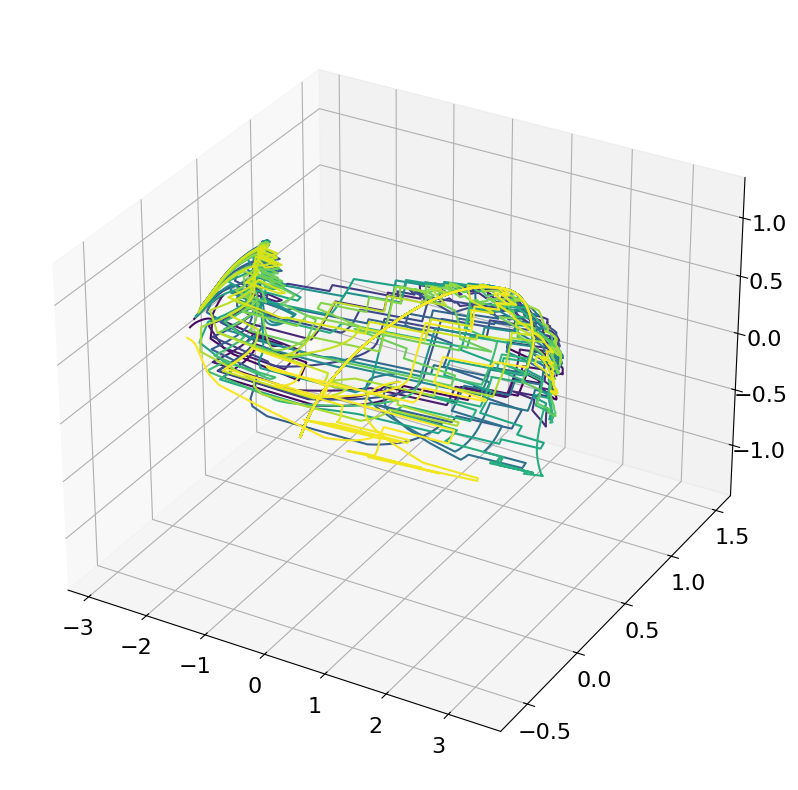

In [20]:
node3_pc_worse = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_NODE_grid_allRates/max_epochs=800_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=0.00E+00_allRates=True_latent_size=3_layer_hidden_size=64_latent_l2_wt=1.00E-08"
node3_pc_worse = Analysis_TT(run_name = "node1", filepath = node3_pc_worse + "/")
node3_pc_worse.plot_trial_latents(num_trials=50, n_components=2)

## TT - LR - grid allRates

* lowest loss in last sweep (_2) min around 0.5. rank 2 and 3 around 1500 epochs just start decreasing - increasing to 2000 epochs

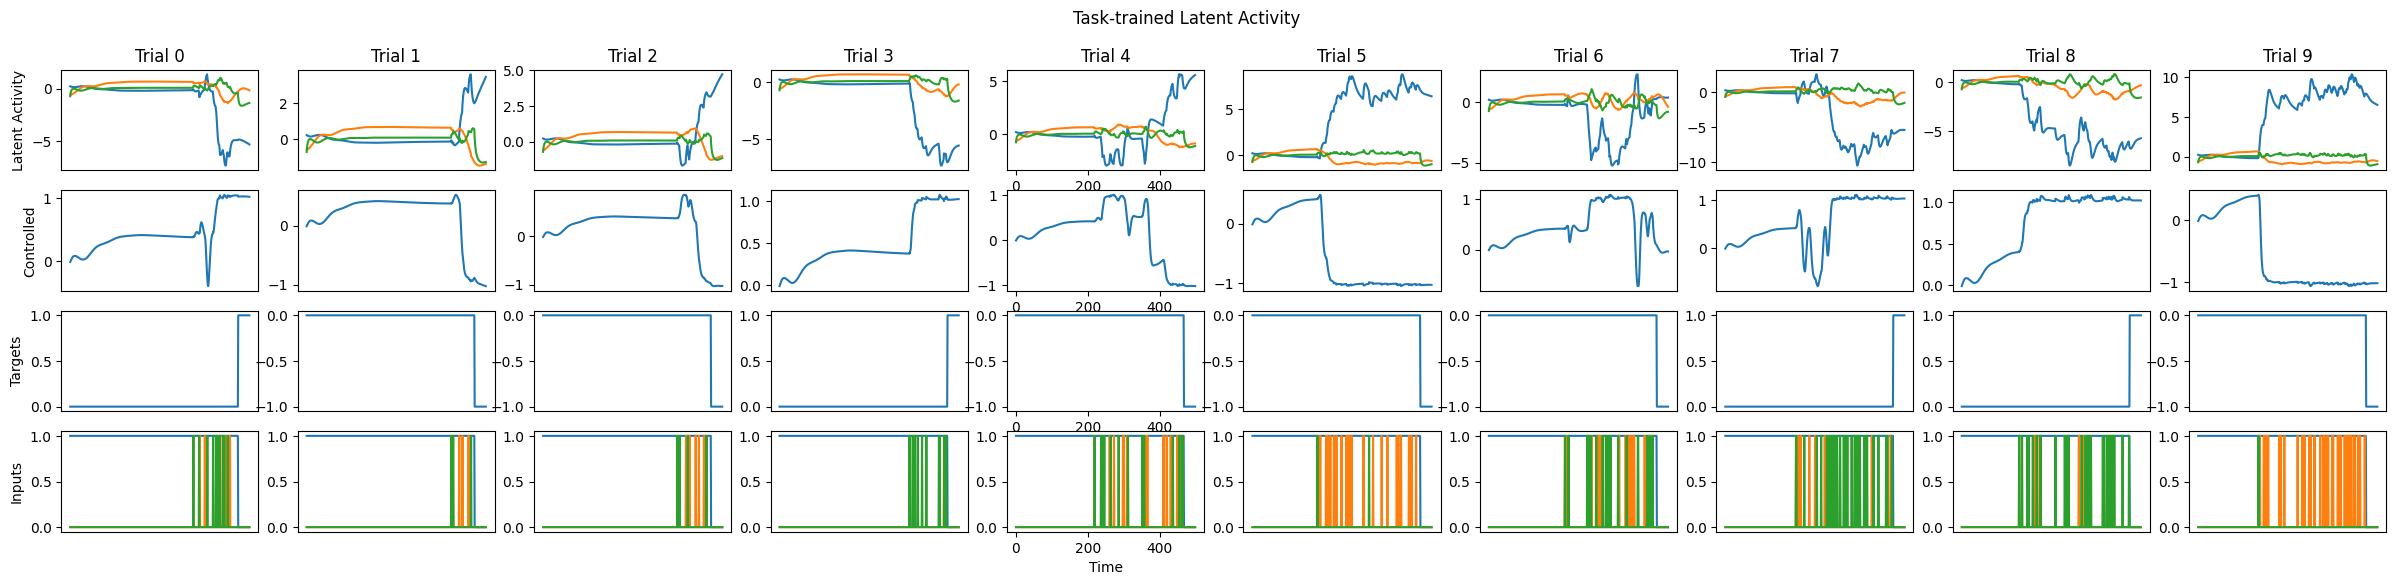

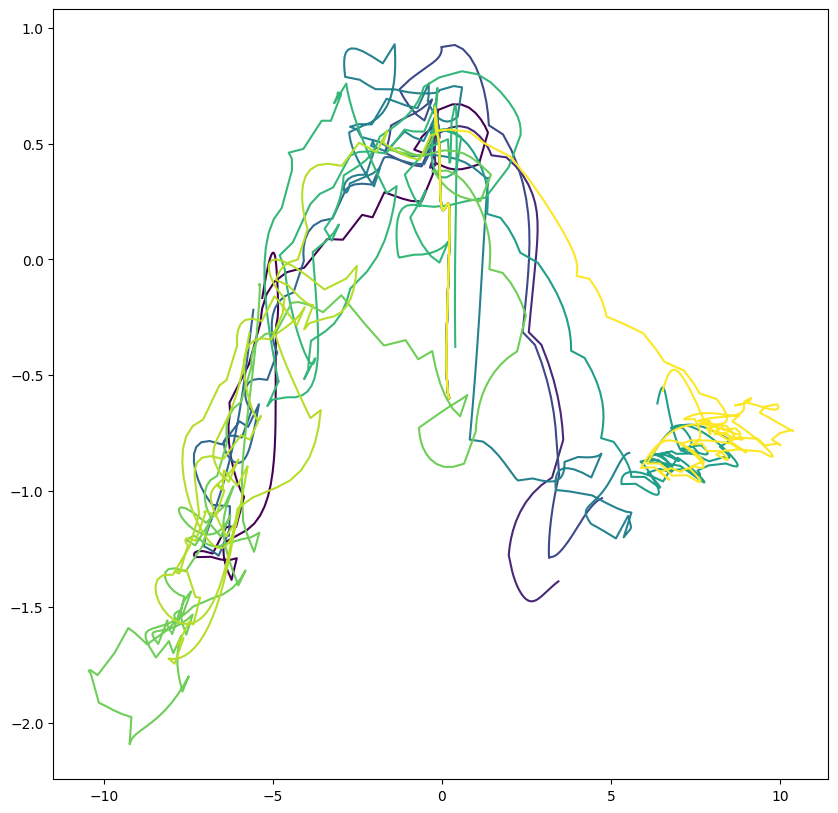

In [3]:
# loss 26 - does not solve it
fr2_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_fr_grid_allRates/max_epochs=800_weight_decay=1.00E-05_learning_rate=1.00E-03_noise=0.00E+00_allRates=True_seed=0_latent_size=2"
fr128_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_fr_grid_allRates/max_epochs=800_weight_decay=1.00E-05_learning_rate=1.00E-03_noise=0.00E+00_allRates=True_seed=0_latent_size=128"

# fr2_pc = Analysis_TT(run_name = "node1", filepath = fr2_pc + "/")
fr128_pc = Analysis_TT(run_name = "node1", filepath = fr128_pc + "/")

fr128_pc.plot_trial_io(num_trials=10)

# also showing PCA
fr128_pc.plot_trial_latents(num_trials=10, n_components=2)

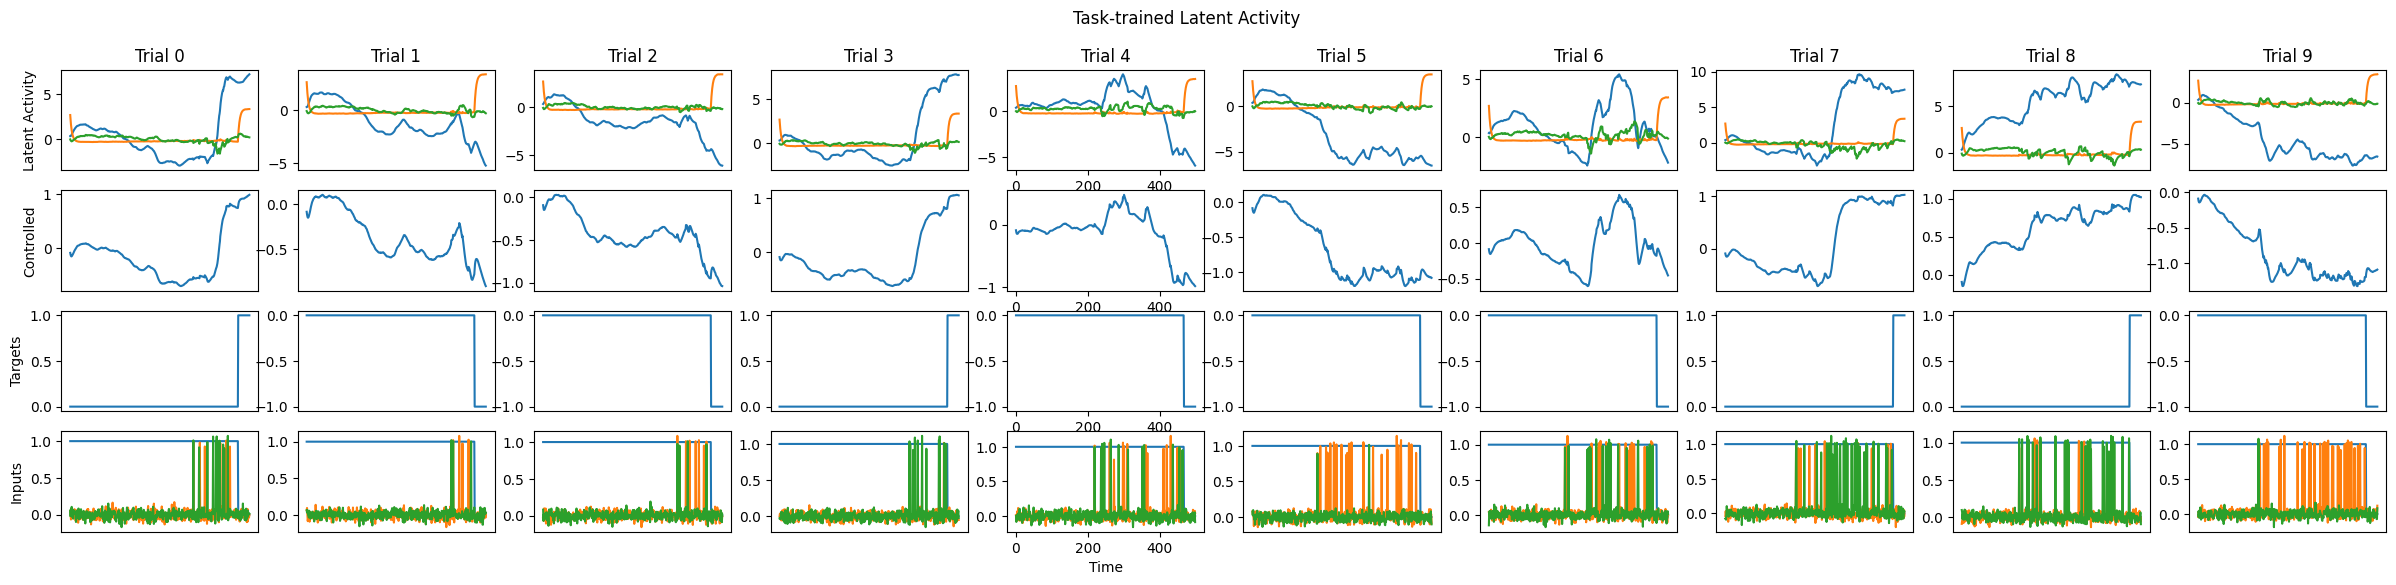

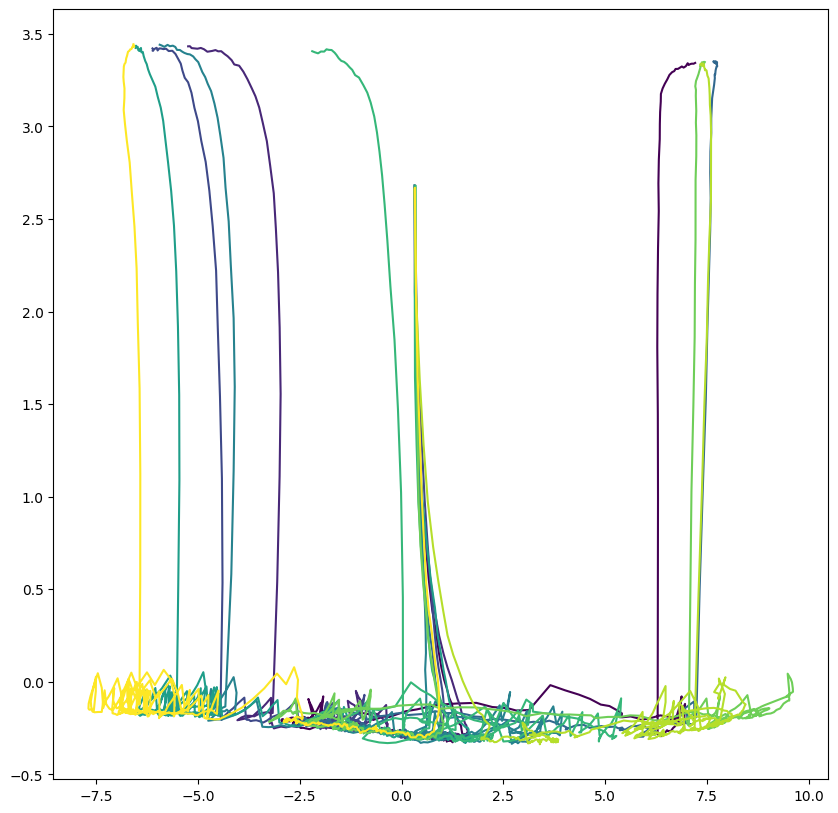

In [2]:
from ctd.comparison.analysis.tt.tt import Analysis_TT
lr128_pc = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250331_PClicks_lr_grid_allRates/max_epochs=800_weight_decay=1.00E-05_learning_rate=1.00E-04_noise=5.00E-02_allRates=True_seed=0_rank=2_latent_size=128"

lr128_pc = Analysis_TT(run_name = "lr128_pc", filepath = lr128_pc + "/")

lr128_pc.plot_trial_io(num_trials=10)

# also showing PCA
lr128_pc.plot_trial_latents(num_trials=10, n_components=2)

## TT for a single rateL 

Notice that

* easy trials actually have models perform worse when the latent size is too big
* the intrinsic flowfield is just (F,0), while the other one that I use has (F,input) - state, which is the same used for FP finder

## Marino Pagan task

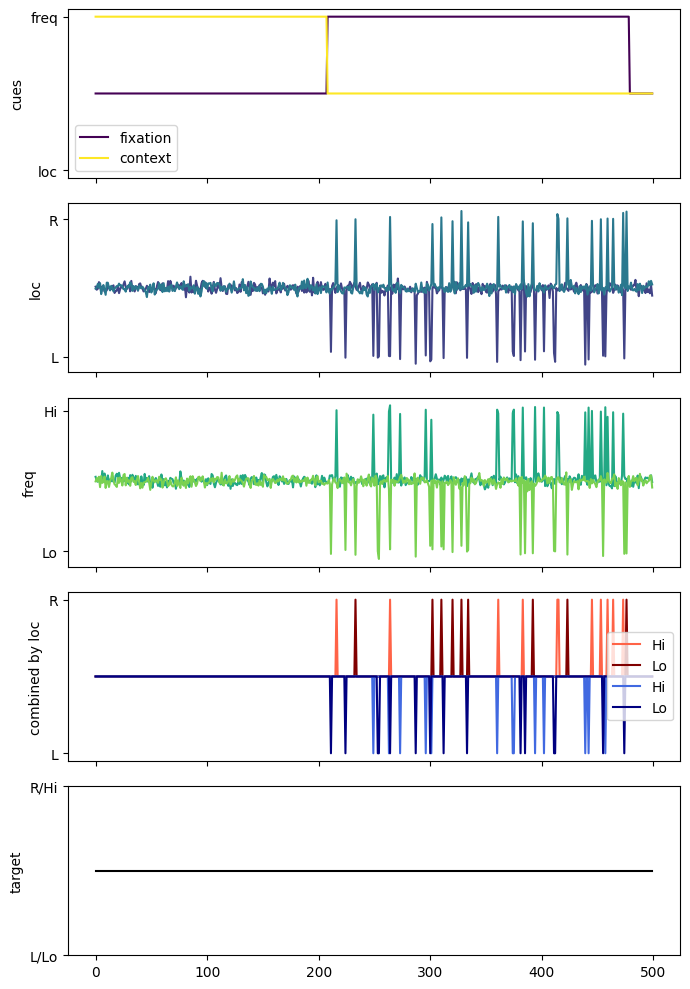

In [8]:
## Marino Pagan task - just like the paper
# note that there is a very small but non-zero chance that the target output should be 0 (if everything has tied)

from ctd.task_modeling.task_env.task_env import MarinoPagan

mp = MarinoPagan(n_timesteps= 500, noise= 0.05, rateL=20)  # Hz

mp.render()

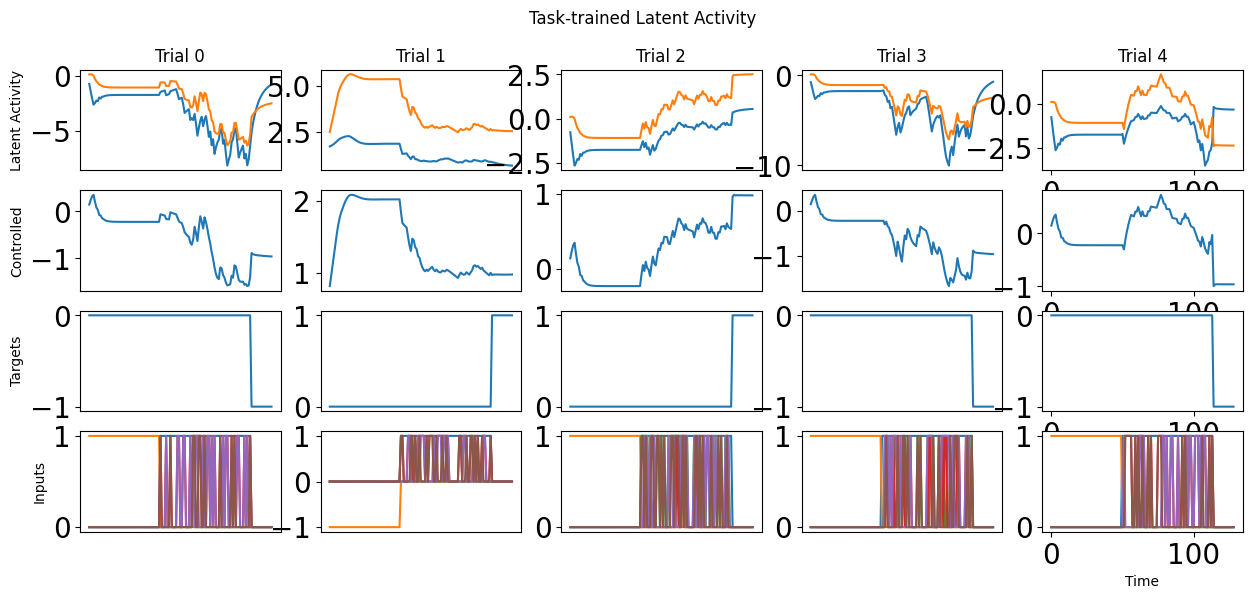

In [28]:
path = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250411_MP_NODE_grid_sweep/max_epochs=1300_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_num_layers=6_latent_l2_wt=1.00E-10_alpha=1.00E-01_leak=True"
node_mp = Analysis_TT(run_name = "node_mp", filepath = path + "/")

node_mp.plot_trial_io(num_trials=5)

In [30]:
from ctd.task_modeling.task_env.task_env import MarinoPagan

# for delta_t 1e-2
mp1e2 = MarinoPagan(n_timesteps= 2000, 
             noise= 0.00, 
             rateL=8,               # Hz
             delta_t=1e-2,           # seconds
             allRates=False, 
            ) 

d1e2, _ = mp1e2.generate_dataset(2000)   # want to make this the same as the wrapper saved input dataset

/scratch/gpfs/ad2002/content/trained_models/task-trained/20250411_MP_NODE_grid_sweep/max_epochs=1300_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_num_layers=6_latent_l2_wt=1.00E-10_alpha=1.00E-01_leak=True


IndexError: index 1 is out of bounds for axis 1 with size 1

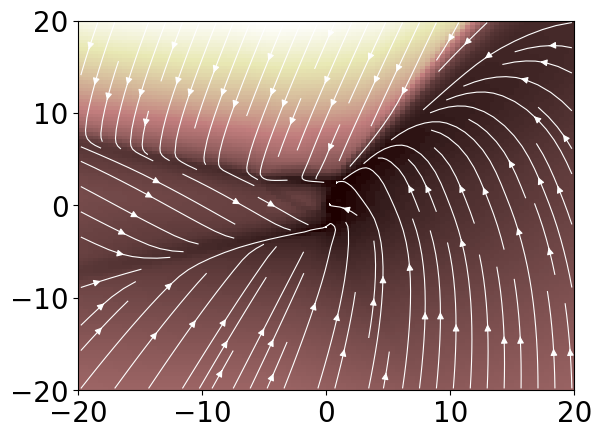

In [31]:
sweep_dir = "/scratch/gpfs/ad2002/content/trained_models/task-trained/20250411_MP_NODE_grid_sweep"

# want to get intrinsic field but NOT the presaved latents
analyze_flow_field(sweep_dir, 
                    sweep_name="/scratch/gpfs/ad2002/content/trained_models/task-trained/20250411_MP_NODE_grid_sweep/max_epochs=1300_weight_decay=1.00E-08_learning_rate=2.00E-03_seed=0_noise=1.70E-04_latent_size=2_layer_hidden_size=128_num_layers=6_latent_l2_wt=1.00E-10_alpha=1.00E-01_leak=True",
                    task_dataset_dict = d1e2, 
                    input_field=np.array([0, 1, 1, 0, 1, 0]),   # [fixation, ctx, left, right, hi, lo]
                    n_trials=500,
                    scatter=True,    # if True, won't color by rate
                    intrinsic=False, 
                    plot_wrapper_trajs=False,
                    avg_per_rate=False,    # averaging does not consider onset of stimulus
                    filter_pc_rate=None,
                    lint_plot_style=True,
                    num_points=100,
                    latents_range=[[-20,20],[-20,20]]
                   )

# advangin on the intrinsic field for IC in the origin does not advance them - adding some noise to the ics

# note that 0 seems to be a saddle point - unstable equilibirum